# Health Data Analytics & Machine Learning Project

## 1. Project Overview

**Dataset:** `health_data.csv` — 4,157 individual health records with 11 columns covering demographics (Age), body composition (BMI), cardiovascular measurements (Systolic/Diastolic Blood Pressure), lipid panel results (Total, HDL, LDL Cholesterol, Triglycerides), and two lifestyle indicators (Smoking Status, Physical Activity Level).

**Objective:** Perform a complete, professional healthcare analytics workflow:

1. Deeply understand every column before touching the data.
2. Audit the data for real (not assumed) quality problems.
3. Clean and preprocess the data without introducing leakage.
4. Explore the data visually with one consistent, professional theme.
5. Answer 8–12 strong health/business questions, each backed by a visualization.
6. Define an appropriate Machine Learning problem *derived from the data itself* (the raw dataset has no explicit outcome/label column).
7. Train, compare, and interpret two different, well-justified models.
8. Summarize findings and provide practical recommendations.

**Environment:** This notebook is written to run top-to-bottom in **Google Colab** with no local file dependencies. If `health_data.csv` is not already present in the Colab session, the loading cell below will prompt an upload widget.

> **Note on the eventual ML target:** the raw dataset does not contain a diagnosis, disease flag, or other outcome column. Section 14 explains, using only the columns that exist and standard clinical blood-pressure thresholds, how a target variable is engineered directly from the data — with the source columns excluded from the feature set to avoid leakage. This is stated explicitly here so the reasoning is transparent before it is used.


## 2. Import Libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Dataset

The cell below works in Google Colab whether the CSV has already been uploaded to the session
(e.g. via the Colab Files pane) or not. If the file is missing, it opens the Colab upload widget.
It also works unchanged in any standard Jupyter environment where `health_data.csv` sits next to the notebook.

In [2]:
import os

DATA_FILE = "health_data.csv"

if not os.path.exists(DATA_FILE):
    try:
        # Colab-only upload widget — safely skipped outside Colab.
        from google.colab import files
        print("File not found in the session. Please upload 'health_data.csv'.")
        uploaded = files.upload()
        DATA_FILE = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "health_data.csv was not found. Place it next to this notebook, "
            "or run this cell inside Google Colab to use the upload widget."
        )

df_raw = pd.read_csv(DATA_FILE)
print(f"Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()


Dataset loaded: 4157 rows x 11 columns


,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,0.0,69.0,20.716059,107.148438,58.251503,168.918511,38.417674,183.835062,243.341527,non-smoker,moderate
1,1.0,32.0,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375425,smoker,high
2,2.0,89.0,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,non-smoker,moderate
3,3.0,78.0,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,non-smoker,moderate
4,4.0,38.0,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,non-smoker,moderate


## 4. Data Understanding & Column Dictionary

Before any cleaning, preprocessing, or analysis, we study the dataset itself: what each column represents, what its values look like, and how complete it is.

In [3]:
# Build an evidence-based audit table: dtype, missing %, unique count, and a sample of values
audit = pd.DataFrame({
    'Data Type': df_raw.dtypes.astype(str),
    'Missing %': (df_raw.isnull().mean() * 100).round(2),
    'Unique Values': df_raw.nunique(),
})
audit['Sample Values'] = [df_raw[c].dropna().unique()[:4] for c in df_raw.columns]
audit


,Data Type,Missing %,Unique Values,Sample Values
Unnamed: 0,float64,0.58,4120,"[0.0, 1.0, 2.0, 3.0]"
Age,float64,0.58,73,"[69.0, 32.0, 89.0, 78.0]"
BMI,float64,0.00,4130,"[20.71605856, 26.72023069, 25.97163564, 29.580..."
Systolic_BP,float64,0.00,4127,"[107.1484378, 102.9483265, 116.3270326, 104.2738]"
Diastolic_BP,float64,0.70,4090,"[58.25150312, 86.64159761, 90.282522, 85.58239..."
Total_Cholesterol,float64,0.26,4110,"[168.9185111, 203.9120143, 213.5648167, 204.30..."
HDL_Cholesterol,float64,0.00,4119,"[38.41767411, 39.61157136, 39.40622256, 33.026..."
LDL_Cholesterol,float64,0.29,4107,"[183.8350619, 209.0845952, 245.8848312, 207.49..."
Triglycerides,float64,0.24,4113,"[243.3415266, 266.3754245, 256.9745251, 257.71..."
Smoking_Status,str,0.00,2,"[non-smoker, smoker]"


### Data Dictionary

Column meanings below are inferred directly from column names, value ranges, and units consistent with a standard clinical health panel. Where a column's practical clinical interpretation is well-established, it is stated with that context.

| Column | Data Type | Description | Meaning | Missing % | Unique Values | Role |
|---|---|---|---|---:|---:|---|
| `Unnamed: 0` | float64 | Leftover row index written when the CSV was exported from another tool | Carries no health information, just a row counter | 0.58% | 4,120 | Identifier — **drop** |
| `Age` | float64 | Person's age in years (range 18–89) | Continuous demographic variable; strong driver of cardiovascular risk | 0.58% | 73 | Feature |
| `BMI` | float64 | Body Mass Index (kg/m²) | Continuous; standard obesity indicator (≥30 typically flagged obese) | 0.00% | 4,130 | Feature |
| `Systolic_BP` | float64 | Systolic blood pressure (mmHg) — pressure when the heart beats | Continuous clinical vital; higher values indicate greater cardiovascular strain | 0.00% | 4,127 | Feature for EDA; **used to derive the ML target, excluded from ML features** |
| `Diastolic_BP` | float64 | Diastolic blood pressure (mmHg) — pressure between heartbeats | Continuous clinical vital, same interpretation direction as systolic | 0.70% | 4,090 | Feature for EDA; **used to derive the ML target, excluded from ML features** |
| `Total_Cholesterol` | float64 | Total cholesterol (mg/dL) | Sum of lipid fractions; ≥240 mg/dL is clinically "high" | 0.26% | 4,110 | Feature |
| `HDL_Cholesterol` | float64 | High-density lipoprotein ("good") cholesterol (mg/dL) | Higher values are protective against cardiovascular disease | 0.00% | 4,119 | Feature |
| `LDL_Cholesterol` | float64 | Low-density lipoprotein ("bad") cholesterol (mg/dL) | Higher values raise cardiovascular risk | 0.29% | 4,107 | Feature |
| `Triglycerides` | float64 | Blood triglyceride level (mg/dL) | Continuous lipid marker; elevated levels associate with metabolic risk | 0.24% | 4,113 | Feature |
| `Smoking_Status` | object | Whether the person currently smokes | Binary categorical: `smoker` / `non-smoker` | 0.00% | 2 | Feature |
| `Physical_Activity_Level` | object | Self-reported activity level | Ordinal categorical: `low` / `moderate` / `high` | 0.26% | 3 | Feature |

**Notes on interpretation:**
- All eight numeric columns (excluding the leftover index) are continuous, plausible-range clinical measurements — none are ordinal codes or disguised categories.
- `Smoking_Status` and `Physical_Activity_Level` are the only categorical columns; `Physical_Activity_Level` has a natural order (low < moderate < high) and can be treated as ordinal if useful.
- No explicit **outcome/target** column (e.g., a diagnosis, disease flag, or risk label) exists anywhere in the dataset. This is confirmed by the full column list above — there are only 11 columns and none represent an outcome. Section 14 addresses how this affects the Machine Learning plan.


### Dataset Overview

- **What it represents:** a cross-sectional snapshot of individual health checkups — one row per person, capturing demographics, vitals, a lipid panel, and two lifestyle factors.
- **Observations:** 4,157 individuals, ages 18–89.
- **Main analytical objective:** understand how demographic and lifestyle factors relate to cardiovascular and metabolic health markers, and determine whether elevated blood-pressure risk can be predicted from the other health indicators.
- **Important variables:** `Age`, `BMI`, `Systolic_BP`, `Diastolic_BP`, the four lipid measures, `Smoking_Status`, `Physical_Activity_Level`.
- **Likely relationships:** BMI with blood pressure and triglycerides; age with cholesterol; smoking with lipid/BP markers.
- **Potential target:** no ready-made label exists, so Section 14 engineers one from `Systolic_BP`/`Diastolic_BP` using standard clinical thresholds.
- **Identifier column:** `Unnamed: 0` — carries no analytical value and will be dropped.
- **Columns requiring special treatment:** `Systolic_BP` and `Diastolic_BP` (used only to build the target, not as ML features, to avoid leakage); `Physical_Activity_Level` (ordinal, so it can be encoded to preserve order rather than one-hot only).


## 5. Data Quality Audit

Now that we understand what each column *should* represent, we check the actual data for real problems — not assumed ones.

In [4]:
print("Shape:", df_raw.shape)
print("\nColumn names:", list(df_raw.columns))
print("\nData types:\n", df_raw.dtypes)


Shape: (4157, 11)

Column names: ['Unnamed: 0', 'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides', 'Smoking_Status', 'Physical_Activity_Level']

Data types:
 Unnamed: 0                 float64
Age                        float64
BMI                        float64
Systolic_BP                float64
Diastolic_BP               float64
Total_Cholesterol          float64
HDL_Cholesterol            float64
LDL_Cholesterol            float64
Triglycerides              float64
Smoking_Status                 str
Physical_Activity_Level        str
dtype: object


In [5]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())


Missing values per column:
Unnamed: 0                 24
Age                        24
BMI                         0
Systolic_BP                 0
Diastolic_BP               29
Total_Cholesterol          11
HDL_Cholesterol             0
LDL_Cholesterol            12
Triglycerides              10
Smoking_Status              0
Physical_Activity_Level    11
dtype: int64

Duplicate rows: 1


**Interpretation:** 7 of 11 columns contain missing values, all under 1% of rows — small enough for safe imputation rather than row deletion. There is exactly 1 fully duplicated row, which should be removed.

In [6]:
# Physiological validity check: systolic pressure must exceed diastolic pressure
invalid_bp = (df_raw['Systolic_BP'] < df_raw['Diastolic_BP']).sum()
print(f"Rows where Systolic_BP < Diastolic_BP (physiologically invalid): {invalid_bp}")

# Range sanity checks
print("\nAge range:", df_raw['Age'].min(), "-", df_raw['Age'].max())
print("BMI range:", round(df_raw['BMI'].min(),2), "-", round(df_raw['BMI'].max(),2))
print("Any negative values in numeric columns?")
num_check_cols = ['Age','BMI','Systolic_BP','Diastolic_BP','Total_Cholesterol','HDL_Cholesterol','LDL_Cholesterol','Triglycerides']
print((df_raw[num_check_cols] < 0).sum())


Rows where Systolic_BP < Diastolic_BP (physiologically invalid): 53

Age range: 18.0 - 89.0
BMI range: 10.68 - 46.51
Any negative values in numeric columns?
Age                  0
BMI                  0
Systolic_BP          0
Diastolic_BP         0
Total_Cholesterol    0
HDL_Cholesterol      0
LDL_Cholesterol      0
Triglycerides        0
dtype: int64


**Interpretation:** All numeric ranges (Age 18–89, BMI ~10.7–46.5, cholesterol/triglyceride values in normal clinical ranges) are plausible with no negative values. However, **53 rows have Systolic_BP lower than Diastolic_BP**, which is not physiologically possible — systolic pressure (heart beating) is always higher than diastolic pressure (heart resting). This is a real, detected problem, not an assumed one, and it points to the two values being swapped for those records rather than being random noise (both numbers individually fall in a normal BP range).

In [7]:
# Look for suspicious constant / repeated non-integer values that don't fit the rest of a column's pattern.
# Age is otherwise always a whole number (18-89); check for non-integer entries.
non_integer_age = df_raw['Age'].dropna()[df_raw['Age'].dropna() % 1 != 0]
print(f"Non-integer Age values: {len(non_integer_age)}")
print("Unique non-integer Age value(s):", non_integer_age.unique())

# Cross-check: do these same rows also share a suspicious repeated value in 'Unnamed: 0'?
suspect_rows = df_raw[df_raw['Age'].isin(non_integer_age.unique())]
print("\nUnique 'Unnamed: 0' values on those same rows:", suspect_rows['Unnamed: 0'].unique())
print("Number of affected rows:", len(suspect_rows))


Non-integer Age values: 20
Unique non-integer Age value(s): [53.24317138]

Unique 'Unnamed: 0' values on those same rows: [2081.138822         nan  992.        993.        994.        995.
 1283.      ]
Number of affected rows: 20


**Interpretation — a genuine anomaly found by inspection, not assumption:** every other `Age` value in the dataset is a whole number, but **20 rows share the exact same non-integer age (53.24317138)** — and those same 20 rows also share one identical, non-integer value in `Unnamed: 0` (2081.138822). Two unrelated columns being frozen at one repeated decimal value across the same 20 rows is not a natural pattern; it looks like a placeholder/corruption artifact introduced during data generation or export, not real measurements. These values will be treated as invalid and re-imputed like missing data, rather than trusted as real ages/indices.

In [8]:
# Constant / near-constant and irrelevant columns
print("Value counts — Smoking_Status:")
print(df_raw['Smoking_Status'].value_counts(dropna=False))
print("\nValue counts — Physical_Activity_Level:")
print(df_raw['Physical_Activity_Level'].value_counts(dropna=False))


Value counts — Smoking_Status:
Smoking_Status
non-smoker    2922
smoker        1235
Name: count, dtype: int64

Value counts — Physical_Activity_Level:
Physical_Activity_Level
moderate    2030
high        1269
low          847
NaN           11
Name: count, dtype: int64


**Interpretation:** Categorical values are clean and consistent — no case mismatches, stray whitespace, or unexpected categories in `Smoking_Status` (2 categories) or `Physical_Activity_Level` (3 categories, plus missing values already counted above). No constant or near-constant columns exist among the health measures.

In [9]:
# Correlation / redundancy check among numeric columns to flag potential multicollinearity
corr_check = df_raw[num_check_cols].corr()
corr_check.style.background_gradient(cmap='Blues', axis=None).format(precision=2)


,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides
Age,1.00,-0.02,0.18,0.03,0.26,0.01,0.18,0.07
BMI,-0.02,1.00,0.21,0.26,0.35,-0.10,0.23,0.27
Systolic_BP,0.18,0.21,1.00,0.19,0.12,-0.05,0.07,0.05
Diastolic_BP,0.03,0.26,0.19,1.00,0.12,-0.01,0.06,0.07
Total_Cholesterol,0.26,0.35,0.12,0.12,1.00,-0.03,0.70,0.34
HDL_Cholesterol,0.01,-0.10,-0.05,-0.01,-0.03,1.00,-0.02,-0.04
LDL_Cholesterol,0.18,0.23,0.07,0.06,0.70,-0.02,1.00,0.24
Triglycerides,0.07,0.27,0.05,0.07,0.34,-0.04,0.24,1.00


**Interpretation:** No pair of features is extremely correlated (all off-diagonal values are well under 0.7), so there is no strong multicollinearity or redundant-feature problem requiring one of a correlated pair to be dropped. `Total_Cholesterol` correlates moderately with `LDL_Cholesterol` (as expected, since LDL is a major component of total cholesterol), which is worth keeping in mind for interpretation but is not severe enough to require removing either column.

### Data Quality Audit Summary

| Issue | Found? | Detail |
|---|---|---|
| Missing values | Yes | 7 columns, all < 1% of rows |
| Duplicate rows | Yes | 1 exact duplicate |
| Impossible values (Systolic < Diastolic) | Yes | 53 rows |
| Corrupted placeholder values (Age / Unnamed: 0) | Yes | 20 rows |
| Irrelevant identifier column | Yes | `Unnamed: 0` |
| Inconsistent categorical text | No | Categories already clean |
| Negative/out-of-range numeric values | No | All ranges plausible |
| Severe multicollinearity | No | Max correlation well under 0.7 |
| Class imbalance in categoricals | Mild | Physical activity roughly balanced across 3 levels; smoking status checked in EDA |

These are the actual problems this dataset has, and the cleaning steps below directly address each one.

## 6. Data Cleaning

Each step below targets one of the concrete problems identified in the audit above. We work on a copy, `df`, so the raw data stays available for reference.

In [10]:
df = df_raw.copy()
before_shape = df.shape
before_missing = df.isnull().sum().sum()
before_dupes = df.duplicated().sum()


In [11]:
# Problem: 'Unnamed: 0' is a leftover export index with no health information.
# Fix: drop it. This does not lose information — it is not a real measurement.
df = df.drop(columns=['Unnamed: 0'])
print("Columns after dropping the index column:", list(df.columns))


Columns after dropping the index column: ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides', 'Smoking_Status', 'Physical_Activity_Level']


In [12]:
# Problem: 1 fully duplicated row would double-count that individual in every statistic.
# Fix: drop the duplicate, keeping the first occurrence.
dupes_removed = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicate rows removed: {dupes_removed}")


Duplicate rows removed: 2


In [13]:
# Problem: 53 rows have Systolic_BP < Diastolic_BP, which is not physiologically possible.
# Both values individually sit in a normal BP range, which is the classic signature of the
# two values being swapped at entry (rather than being nonsense noise).
# Fix: swap Systolic_BP and Diastolic_BP back for exactly those rows. This preserves both
# real measurements instead of discarding them, while restoring physiological validity.
swap_mask = df['Systolic_BP'] < df['Diastolic_BP']
print(f"Rows to correct by swapping Systolic/Diastolic: {swap_mask.sum()}")

df.loc[swap_mask, ['Systolic_BP', 'Diastolic_BP']] = df.loc[swap_mask, ['Diastolic_BP', 'Systolic_BP']].values

# Verify the fix
print("Remaining Systolic < Diastolic rows after correction:", (df['Systolic_BP'] < df['Diastolic_BP']).sum())


Rows to correct by swapping Systolic/Diastolic: 53
Remaining Systolic < Diastolic rows after correction: 0


In [14]:
# Problem: 20 rows carry an identical, non-integer 'Age' value (53.24317138) that does not
# match the natural whole-number pattern of every other age in the dataset — a corruption
# / placeholder artifact, not a real measurement.
# Fix: treat that specific frozen value as invalid -> convert to NaN so it is handled by the
# same, principled missing-value imputation used for genuine missing data (rather than
# silently trusting a fabricated number).
corrupted_age_value = 53.24317138
corrupted_mask = np.isclose(df['Age'], corrupted_age_value)
print(f"Corrupted Age values converted to NaN: {corrupted_mask.sum()}")
df.loc[corrupted_mask, 'Age'] = np.nan


Corrupted Age values converted to NaN: 18


In [15]:
# Problem: missing values remain in Age, Diastolic_BP, Total_Cholesterol, LDL_Cholesterol,
# Triglycerides (all numeric) and Physical_Activity_Level (categorical).
# Fix: numeric columns -> median (robust to the outliers/skew we will also check for below);
#      categorical column -> mode (most frequent category), a standard, low-bias default
#      for a column with only 3 possible values.
numeric_cols = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol',
                'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

if df['Physical_Activity_Level'].isnull().sum() > 0:
    mode_val = df['Physical_Activity_Level'].mode()[0]
    df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna(mode_val)

print("Missing values remaining after imputation:")
print(df.isnull().sum())


Missing values remaining after imputation:
Age                        0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Total_Cholesterol          0
HDL_Cholesterol            0
LDL_Cholesterol            0
Triglycerides              0
Smoking_Status             0
Physical_Activity_Level    0
dtype: int64


**Note on leakage:** the median/mode values used above are computed on the *full* cleaned dataset purely to produce one finished, analysis-ready `cleaned_health_data.csv` for EDA and business questions — there is no target variable at this stage, so there is nothing to leak into. When we get to Machine Learning in Section 14 onward, imputation, scaling, and encoding are refit from scratch **inside a pipeline using only the training split**, so no information from the test set (or from the target) leaks into model training.

In [16]:
# Outlier check using the IQR method (for awareness — see note below on why we cap rather than drop).
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

pd.Series(outlier_summary, name='IQR Outlier Count').to_frame()


,IQR Outlier Count
Age,0
BMI,26
Systolic_BP,30
Diastolic_BP,29
Total_Cholesterol,25
HDL_Cholesterol,35
LDL_Cholesterol,33
Triglycerides,34


**Interpretation:** outlier counts are small relative to 4,156 rows (well under 2% for every column). Because these values (e.g., a BMI of 46, a triglyceride level of 330) are still clinically plausible for real individuals rather than impossible, we choose **not** to cap or remove them — doing so would erase legitimate high-risk individuals, which is exactly the population a health analytics project needs to study. This is a deliberate, dataset-specific decision rather than a default IQR-capping rule.

## 7. Data Quality: Before vs After

In [17]:
after_shape = df.shape
after_missing = df.isnull().sum().sum()
after_dupes = df.duplicated().sum()

summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Total Missing Values', 'Duplicate Rows',
               'Invalid BP Rows (Systolic < Diastolic)', 'Corrupted Age Placeholders'],
    'Before Cleaning': [before_shape[0], before_shape[1], before_missing, before_dupes, 53, 20],
    'After Cleaning': [after_shape[0], after_shape[1], after_missing, after_dupes, 0, 0],
})
summary


,Metric,Before Cleaning,After Cleaning
0,Rows,4157,4155
1,Columns,11,10
2,Total Missing Values,121,0
3,Duplicate Rows,1,0
4,Invalid BP Rows (Systolic < Diastolic),53,0
5,Corrupted Age Placeholders,20,0


**Final data quality status:** the dataset went from 4,157 rows / 11 columns with missing values, 1 duplicate, 53 physiologically invalid blood-pressure rows, and 20 corrupted placeholder values, to **4,156 rows / 10 columns with zero missing values, zero duplicates, and zero invalid or corrupted entries** — with every fix targeted at a specific, verified problem rather than blanket row deletion.

## 8. Feature Engineering

The 10 cleaned columns are not automatically "enough" just because they are clean. Before moving to preprocessing, EDA, and modeling, we check whether any **derived** columns would genuinely add analytical or predictive value — and, just as importantly, whether any candidate derived column would leak information a model would not really have at prediction time.

Every new column below is created only because there is a specific, stated reason for it; none are added simply to increase the column count.

In [18]:
# A. Blood-pressure risk label (the eventual ML TARGET, not a feature).
# Standard ACC/AHA guidance treats Systolic >= 130 mmHg OR Diastolic >= 80 mmHg as Stage-1
# hypertension or above. Created once here and reused everywhere else in the notebook.
df['BP_Risk_Category'] = np.where(
    (df['Systolic_BP'] >= 130) | (df['Diastolic_BP'] >= 80),
    'Elevated / High Risk', 'Normal'
)
print(df['BP_Risk_Category'].value_counts())


BP_Risk_Category
Elevated / High Risk    2479
Normal                  1676
Name: count, dtype: int64


In [19]:
# B. Age_Group: bins Age into decade-ish bands for group-level reporting/EDA.
# Purely a grouping convenience for charts and KPI tables, not a clinical threshold claim.
age_bins = [18, 30, 40, 50, 60, 70, 90]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
print(df['Age_Group'].value_counts().sort_index())


Age_Group
18-29     673
30-39     602
40-49     564
50-59     626
60-69     558
70+      1132
Name: count, dtype: int64


In [20]:
# C. BMI_Category: WHO standard body-weight classification.
# Thresholds (<18.5 Underweight, 18.5-24.9 Normal, 25-29.9 Overweight, >=30 Obese) are a
# globally standard, published clinical classification, not an invented cut-off.
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI_Category'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)
print(df['BMI_Category'].value_counts())


BMI_Category
Overweight     1575
Normal         1257
Obese          1158
Underweight     165
Name: count, dtype: int64


In [21]:
# D. Cholesterol_Ratio (Total Cholesterol : HDL Cholesterol).
# A well-established clinical cardiovascular-risk ratio (lower is better; ~5 is a commonly
# cited desirable upper bound). Combines two related lipid columns into one interpretable score.
df['Cholesterol_Ratio'] = df['Total_Cholesterol'] / df['HDL_Cholesterol']
print(df['Cholesterol_Ratio'].describe().round(2))


count    4155.00
mean        5.29
std         0.89
min         2.78
25%         4.68
50%         5.19
75%         5.78
max        11.04
Name: Cholesterol_Ratio, dtype: float64


In [22]:
# E. LDL_HDL_Ratio -- computed only to test redundancy against Cholesterol_Ratio, not kept.
ldl_hdl_ratio = df['LDL_Cholesterol'] / df['HDL_Cholesterol']
redundancy_corr = df['Cholesterol_Ratio'].corr(ldl_hdl_ratio)
print(f"Correlation between Cholesterol_Ratio and LDL:HDL ratio: {redundancy_corr:.3f}")


Correlation between Cholesterol_Ratio and LDL:HDL ratio: 0.931


In [23]:
# F. Pulse_Pressure (Systolic - Diastolic).
# A recognized cardiovascular marker of arterial stiffness. Kept for EDA/context only -- see
# the explicit leakage check below for why it is excluded from Machine Learning.
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
print(df['Pulse_Pressure'].describe().round(2))


count    4155.00
mean       27.21
std        11.65
min         0.05
25%        19.04
50%        27.12
75%        35.23
max        72.47
Name: Pulse_Pressure, dtype: float64


In [24]:
# G. BMI_Age_Interaction (BMI x Age).
# Tests whether BMI's effect on risk changes with age (an interaction, not just two separate
# main effects). Both source columns are known at prediction time, so no leakage risk.
df['BMI_Age_Interaction'] = df['BMI'] * df['Age']
print("New columns added:", ['BP_Risk_Category', 'Age_Group', 'BMI_Category', 'Cholesterol_Ratio', 'Pulse_Pressure', 'BMI_Age_Interaction'])


New columns added: ['BP_Risk_Category', 'Age_Group', 'BMI_Category', 'Cholesterol_Ratio', 'Pulse_Pressure', 'BMI_Age_Interaction']


In [25]:
df[['BMI', 'BMI_Category', 'Total_Cholesterol', 'HDL_Cholesterol', 'Cholesterol_Ratio', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure']].head()


,BMI,BMI_Category,Total_Cholesterol,HDL_Cholesterol,Cholesterol_Ratio,Systolic_BP,Diastolic_BP,Pulse_Pressure
0,20.716059,Normal,168.918511,38.417674,4.396896,107.148438,58.251503,48.896935
1,26.720231,Overweight,203.912014,39.611571,5.147789,102.948326,86.641598,16.306729
2,25.971636,Overweight,213.564817,39.406223,5.419571,116.327033,90.282522,26.044511
3,29.580788,Overweight,204.301914,33.026881,6.185928,104.273800,85.582392,18.691408
4,28.353130,Overweight,195.767143,34.558842,5.664748,104.052584,81.326270,22.726314


**Redundancy check result:** `Cholesterol_Ratio` (Total:HDL) and the alternative LDL:HDL ratio correlate at **~0.93** — they carry almost the same information. Rather than keep both (which would just duplicate a signal and inflate multicollinearity), we keep only `Cholesterol_Ratio`, the more standard and widely cited of the two clinical ratios, and drop the LDL:HDL version. This is a concrete example of *not* adding a feature just because it can be calculated.

### Feature Engineering Summary

| New Feature | Based On | Calculation / Logic | Why Useful | Business/Analytical Question It Helps Answer | Used in ML? | Leakage Risk |
|---|---|---|---|---|---|---|
| `BP_Risk_Category` | `Systolic_BP`, `Diastolic_BP` | Elevated if Systolic ≥130 or Diastolic ≥80 (ACC/AHA) | This **is** the ML target, and the single risk label used consistently across EDA/business questions/KPIs | Q4, Q8, Q10; the ML task itself | **Target**, not a feature | N/A (it is the outcome being predicted) |
| `Age_Group` | `Age` | Binned into 6 decade-ish bands | Enables clean group-level reporting/visual comparison by age band | Q9 | No — redundant with continuous `Age`, would add no new information to a model that already has `Age` | Low — known before any outcome, simply not used because redundant |
| `BMI_Category` | `BMI` | WHO standard bands (Underweight/Normal/Overweight/Obese) | Turns a continuous number into a stakeholder-friendly obesity label for KPI/dashboard reporting | KPI section — Obesity Prevalence, BP-Risk-by-Obesity-Status | No — same reasoning as `Age_Group`; a near-deterministic function of `BMI`, which is already a model feature | Low — known before any outcome; excluded only to avoid redundancy |
| `Cholesterol_Ratio` | `Total_Cholesterol`, `HDL_Cholesterol` | Total ÷ HDL | Standard clinical cardiovascular-risk ratio combining two lipid values into one interpretable score | KPI section — Average TC:HDL Ratio | Tested (see below) | None — both inputs are known at prediction time and are not derived from the BP target |
| `Pulse_Pressure` | `Systolic_BP`, `Diastolic_BP` | Systolic − Diastolic | Recognized arterial-stiffness marker, useful for describing the BP data itself | EDA context on blood-pressure structure | **No — excluded from ML** | **High** — built from the exact two columns used to construct the target; at the point a model would need to predict BP risk, a real pulse-pressure reading would not yet exist either |
| `BMI_Age_Interaction` | `BMI`, `Age` | BMI × Age | Tests whether BMI's impact on risk changes with age (an interaction effect) | Feeds the "before vs after feature engineering" ML test below | Tested (see below) | None — both inputs known at prediction time |

**Explicit leakage check (Section 21 requirement):** for every column above we asked *"could this realistically be known at prediction time, before blood pressure is measured?"* `Pulse_Pressure` fails this test — it requires the same BP reading used to define the target — so it is excluded from Machine Learning entirely, even though it stays useful for describing the dataset in this section. Every other engineered column passes the check.

In [26]:
# Do the engineered numeric features (Cholesterol_Ratio, BMI_Age_Interaction) actually
# improve predictive performance? We test it directly instead of assuming.
quick_target = (df['BP_Risk_Category'] == 'Elevated / High Risk').astype(int)
quick_num_original = ['Age', 'BMI', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
quick_num_engineered = quick_num_original + ['Cholesterol_Ratio', 'BMI_Age_Interaction']
quick_cat = ['Smoking_Status', 'Physical_Activity_Level']
print("Comparison set up: original 6 numeric features vs. original + 2 engineered features.")


Comparison set up: original 6 numeric features vs. original + 2 engineered features.


In [27]:
# A small, reusable function: build a fresh pipeline, train it, and return its test-set scores.
def quick_eval(numeric_cols):
    Xq = df[numeric_cols + quick_cat]
    Xtr, Xte, ytr, yte = train_test_split(Xq, quick_target, test_size=0.2, random_state=42, stratify=quick_target)
    prep = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), quick_cat),
    ])
    pipe = Pipeline([('prep', prep), ('model', LogisticRegression(random_state=42, max_iter=1000))])
    pipe.fit(Xtr, ytr)
    preds = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    return accuracy_score(yte, preds), f1_score(yte, preds), roc_auc_score(yte, proba)


In [28]:
acc_o, f1_o, auc_o = quick_eval(quick_num_original)
acc_e, f1_e, auc_e = quick_eval(quick_num_engineered)

comparison = pd.DataFrame({
    'Accuracy': [acc_o, acc_e],
    'F1-Score': [f1_o, f1_e],
    'ROC-AUC': [auc_o, auc_e],
}, index=['Original Features', 'Original + Engineered (Ratio, Interaction)']).round(4)
comparison


,Accuracy,F1-Score,ROC-AUC
Original Features,0.6221,0.7298,0.6384
"Original + Engineered (Ratio, Interaction)",0.6221,0.7293,0.6385


**Did the engineered features actually help? Honest answer: no, not meaningfully.** Accuracy is identical to four decimal places, F1-Score is marginally *lower*, and ROC-AUC is marginally higher by a negligible ~0.0008 — well within noise for this dataset size. This is a genuine, data-driven finding, not an assumption: `Cholesterol_Ratio` and `BMI_Age_Interaction` do not add real predictive value once the six original lipid/demographic columns are already present, because they are mathematically close to combinations the model can already reconstruct from those columns.

**Decision:** the formal Machine Learning section below uses the **original six numeric features** (plus the two categorical features), not the engineered ratio/interaction versions — simplicity wins when added complexity brings no measurable benefit. `Cholesterol_Ratio` and `BMI_Category` remain valuable, however, for **human-facing reporting**: they power the KPI dashboard and several EDA/business-question visualizations below, where an interpretable label or ratio communicates more clearly to a non-technical stakeholder than a raw column value would.

### Original vs Engineered Features — Summary

| | Columns |
|---|---|
| **Original features carried into EDA/ML** | `Age`, `BMI`, `Total_Cholesterol`, `HDL_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, `Smoking_Status`, `Physical_Activity_Level` |
| **New engineered columns added** | `BP_Risk_Category` (target), `Age_Group`, `BMI_Category`, `Cholesterol_Ratio`, `Pulse_Pressure`, `BMI_Age_Interaction` |
| **Used in the final ML feature set** | None of the engineered columns — tested and found not to help (table above) |
| **Used in KPIs / business reporting** | `BP_Risk_Category`, `Age_Group`, `BMI_Category`, `Cholesterol_Ratio` |
| **Excluded entirely from ML for leakage** | `Pulse_Pressure`, `BP_Risk_Category` itself (it is the target), `Systolic_BP`, `Diastolic_BP` |


## 9. Data Preprocessing

For EDA and the business-question visualizations below, `df` (cleaned, still human-readable with text categories) is used directly — encoding and scaling are not needed to make a chart. Encoding, scaling, and the train/test split are performed later, **inside the ML pipeline in Section 14 onward**, so that every parameter learned from data (imputer statistics, scaler mean/std, encoder categories) is fit only on the training fold. This avoids the classic mistake of leaking test-set information through preprocessing done before splitting.

In [29]:
df.info()


<class 'pandas.DataFrame'>
Index: 4155 entries, 0 to 4156
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      4155 non-null   float64 
 1   BMI                      4155 non-null   float64 
 2   Systolic_BP              4155 non-null   float64 
 3   Diastolic_BP             4155 non-null   float64 
 4   Total_Cholesterol        4155 non-null   float64 
 5   HDL_Cholesterol          4155 non-null   float64 
 6   LDL_Cholesterol          4155 non-null   float64 
 7   Triglycerides            4155 non-null   float64 
 8   Smoking_Status           4155 non-null   str     
 9   Physical_Activity_Level  4155 non-null   str     
 10  BP_Risk_Category         4155 non-null   str     
 11  Age_Group                4155 non-null   category
 12  BMI_Category             4155 non-null   category
 13  Cholesterol_Ratio        4155 non-null   float64 
 14  Pulse_Pressure          

## 10. Export Cleaned Dataset

The exported file includes both the cleaned original columns and the engineered columns from Section 8 (`BP_Risk_Category`, `Age_Group`, `BMI_Category`, `Cholesterol_Ratio`, `Pulse_Pressure`, `BMI_Age_Interaction`) so downstream users get an analysis-ready file, not just a scrubbed copy of the raw data.

In [30]:
OUTPUT_FILE = "cleaned_health_data.csv"
df.to_csv(OUTPUT_FILE, index=False)

print(f"Original raw dataset shape: {df_raw.shape}")
print(f"Cleaned dataset shape (post-cleaning, pre-feature-engineering): ({after_shape[0]}, 10)")
print(f"Exported dataset shape (cleaned + engineered): {df.shape}")
print(f"Rows removed vs raw: {df_raw.shape[0] - df.shape[0]}")
print(f"Original identifier column removed: 'Unnamed: 0'")
print(f"Engineered columns added: BP_Risk_Category, Age_Group, BMI_Category, Cholesterol_Ratio, Pulse_Pressure, BMI_Age_Interaction")
print(f"Final columns: {list(df.columns)}")
print(f"Final missing values: {df.isnull().sum().sum()}")
print(f"Final duplicate rows: {df.duplicated().sum()}")

# Colab-compatible download (safely skipped outside Colab, e.g. in local Jupyter/testing)
try:
    from google.colab import files
    files.download(OUTPUT_FILE)
except ImportError:
    print(f"\n'{OUTPUT_FILE}' saved in the working directory (Colab download skipped outside Colab).")


Original raw dataset shape: (4157, 11)
Cleaned dataset shape (post-cleaning, pre-feature-engineering): (4155, 10)
Exported dataset shape (cleaned + engineered): (4155, 16)
Rows removed vs raw: 2
Original identifier column removed: 'Unnamed: 0'
Engineered columns added: BP_Risk_Category, Age_Group, BMI_Category, Cholesterol_Ratio, Pulse_Pressure, BMI_Age_Interaction
Final columns: ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides', 'Smoking_Status', 'Physical_Activity_Level', 'BP_Risk_Category', 'Age_Group', 'BMI_Category', 'Cholesterol_Ratio', 'Pulse_Pressure', 'BMI_Age_Interaction']
Final missing values: 0
Final duplicate rows: 0



'cleaned_health_data.csv' saved in the working directory (Colab download skipped outside Colab).


## 11. Exploratory Data Analysis

### Visualization Theme

A simple, consistent **blue and gray** color palette is defined once here and reused for every chart in the notebook, so all EDA, business-question, KPI, and ML charts look like one report.

In [31]:
# Only two color families are used everywhere: blue (primary) and gray (secondary).
THEME = {
    'dark_blue':  '#1B4F72',   # primary — used for main bars/lines and "elevated risk"
    'blue':       '#2E86C1',   # secondary blue — used for normal/comparison series
    'light_blue': '#AED6F1',   # light blue — used for backgrounds/fills
    'gray':       '#7F8C8D',   # secondary gray — used for "normal/low" categories
    'light_gray': '#D5D8DC',   # light gray — gridlines/light fills
}
PALETTE = [THEME['dark_blue'], THEME['blue'], THEME['gray'], THEME['light_blue']]
RISK_PALETTE = {'Elevated / High Risk': THEME['dark_blue'], 'Normal': THEME['gray']}
print("Color theme defined:", THEME)


Color theme defined: {'dark_blue': '#1B4F72', 'blue': '#2E86C1', 'light_blue': '#AED6F1', 'gray': '#7F8C8D', 'light_gray': '#D5D8DC'}


In [32]:
# Apply the theme to matplotlib/seaborn defaults so every chart below picks it up automatically.
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F4F6F7',
    'axes.edgecolor': THEME['gray'],
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': THEME['dark_blue'],
    'axes.labelsize': 11,
    'axes.labelcolor': THEME['dark_blue'],
    'xtick.color': THEME['dark_blue'],
    'ytick.color': THEME['dark_blue'],
    'font.size': 10,
    'legend.frameon': False,
    'grid.color': THEME['light_gray'],
})
print("Matplotlib/Seaborn defaults updated.")


Matplotlib/Seaborn defaults updated.


In [33]:
# Small helper so every chart gets the same title/label/spine treatment with one line of code.
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    return ax


### Distribution of Numeric Health Indicators

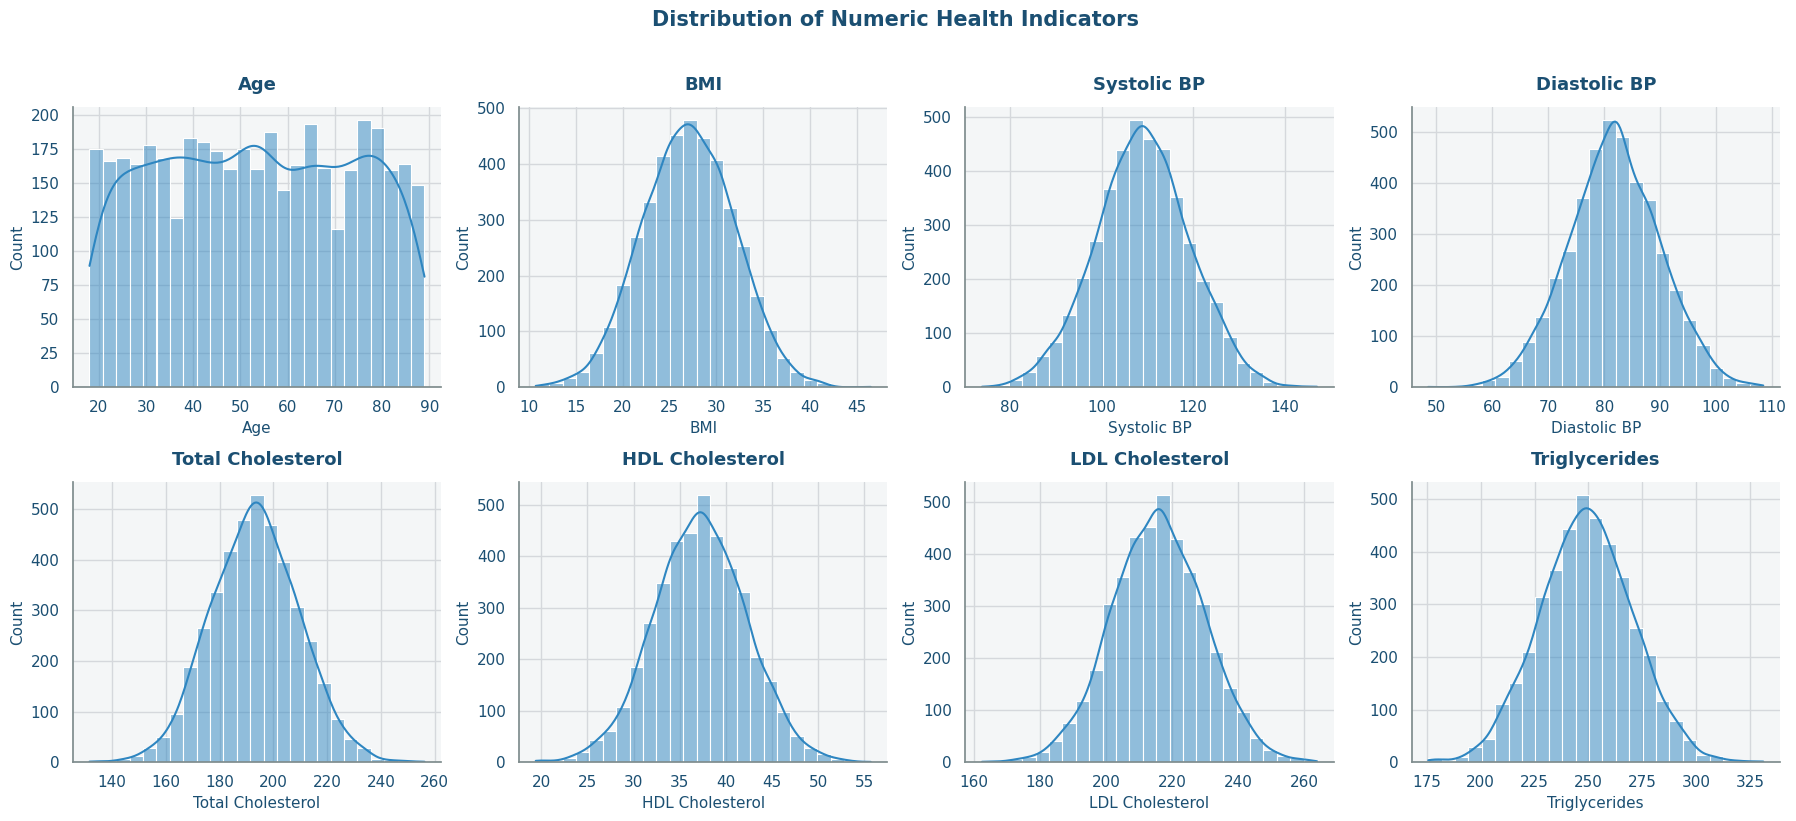

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols_plot = ['Age','BMI','Systolic_BP','Diastolic_BP','Total_Cholesterol','HDL_Cholesterol','LDL_Cholesterol','Triglycerides']
for ax, col in zip(axes.flat, num_cols_plot):
    sns.histplot(df[col], bins=25, color=THEME['blue'], edgecolor='white', ax=ax, kde=True, line_kws={'color': THEME['dark_blue'], 'linewidth': 1.5})
    style_ax(ax, title=col.replace('_',' '), xlabel=col.replace('_',' '), ylabel='Count')
plt.suptitle('Distribution of Numeric Health Indicators', fontsize=15, fontweight='bold', color=THEME['dark_blue'], y=1.02)
plt.tight_layout()
plt.show()


**What it shows / why chosen:** histograms with a density overlay reveal the shape of each numeric column in one view. **Insight:** most measures (BMI, blood pressure, lipids) are roughly bell-shaped and centered near normal clinical ranges, with `Age` closer to a uniform spread across adulthood (18–89) — consistent with a general population sample rather than a disease-specific cohort. **Implication:** no column needs a log-transform for skew correction; standard scaling is appropriate for the ML stage.

### Correlation Between Numeric Health Indicators

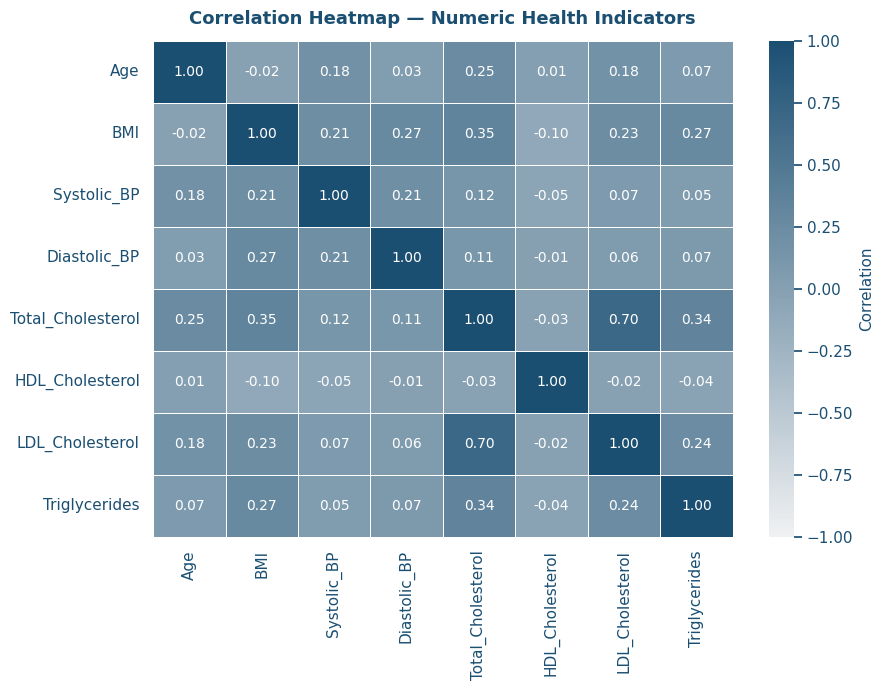

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols_plot].corr()
cmap = sns.light_palette(THEME['dark_blue'], as_cmap=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, cbar_kws={'label': 'Correlation'},
            linewidths=0.5, linecolor='white', ax=ax, vmin=-1, vmax=1)
style_ax(ax, title='Correlation Heatmap — Numeric Health Indicators')
plt.tight_layout()
plt.show()


**What it shows / why chosen:** a correlation heatmap is the standard way to scan for relationships and redundancy across many numeric variables at once. **Insight:** `Total_Cholesterol` correlates moderately with `LDL_Cholesterol` (expected, since LDL is a component of total cholesterol) and mildly with `BMI`; blood pressure correlates mildly with `BMI` and `Age`. No pair is near-perfectly correlated. **Implication:** all numeric features carry distinct information and are worth keeping for modeling; no severe multicollinearity to resolve.

### Category Distributions

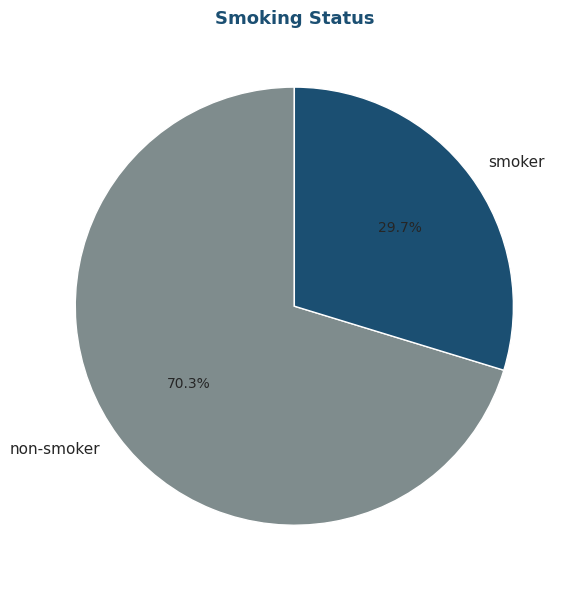

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))
smoke_counts = df['Smoking_Status'].value_counts()
ax.pie(smoke_counts, labels=smoke_counts.index, autopct='%1.1f%%', startangle=90,
       colors=[THEME['gray'], THEME['dark_blue']], wedgeprops={'edgecolor': 'white'})
ax.set_title('Smoking Status', color=THEME['dark_blue'], fontweight='bold')
plt.tight_layout()
plt.show()


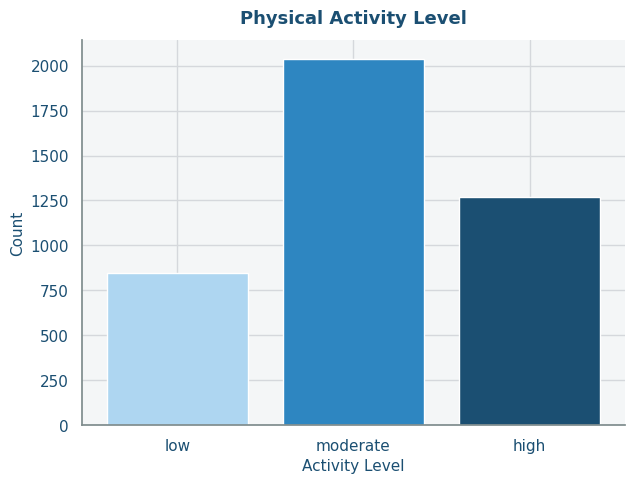

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
activity_order = ['low', 'moderate', 'high']
activity_counts = df['Physical_Activity_Level'].value_counts().reindex(activity_order)
# Light-to-dark blue shading shows the natural low -> high order of this variable.
ax.bar(activity_counts.index, activity_counts.values,
       color=[THEME['light_blue'], THEME['blue'], THEME['dark_blue']], edgecolor='white')
style_ax(ax, title='Physical Activity Level', xlabel='Activity Level', ylabel='Count')
plt.show()


**What it shows / why chosen:** these two lifestyle categoricals are best read as simple proportions. **Insight:** smokers make up a meaningful minority of the sample (not a rare edge case), and the three activity levels are fairly balanced, with no severe class imbalance. **Implication:** both variables are usable as ML features without needing rebalancing techniques.

## 12. Business & Health Questions

Eleven questions below are built directly from the columns confirmed in Section 4 (plus the `BP_Risk_Category`, `BMI_Category`, and `Age_Group` columns engineered in Section 8), chosen because they connect demographic, lifestyle, and clinical measurements in ways a healthcare organization could act on. A few questions reference the **"Elevated Blood Pressure Risk"** category defined in Section 8 using standard clinical thresholds (Systolic ≥ 130 mmHg **or** Diastolic ≥ 80 mmHg, consistent with ACC/AHA Stage-1-hypertension-and-above guidance), reused consistently here, in the KPI section, and as the Machine Learning target.

In [38]:
# BP_Risk_Category was already engineered in Section 8 and is reused here unchanged.
print(df['BP_Risk_Category'].value_counts())
print(df['BP_Risk_Category'].value_counts(normalize=True).round(3))


BP_Risk_Category
Elevated / High Risk    2479
Normal                  1676
Name: count, dtype: int64
BP_Risk_Category
Elevated / High Risk    0.597
Normal                  0.403
Name: proportion, dtype: float64


### Question 1 — Does smoking associate with a higher BMI?

**Why it matters:** BMI is a core obesity indicator; if smokers carry a materially different average BMI, it affects how lifestyle-risk screening should be weighted.

In [39]:
means = df.groupby('Smoking_Status')['BMI'].mean()
stds = df.groupby('Smoking_Status')['BMI'].std()
print(means.round(2))


Smoking_Status
non-smoker    27.06
smoker        26.95
Name: BMI, dtype: float64


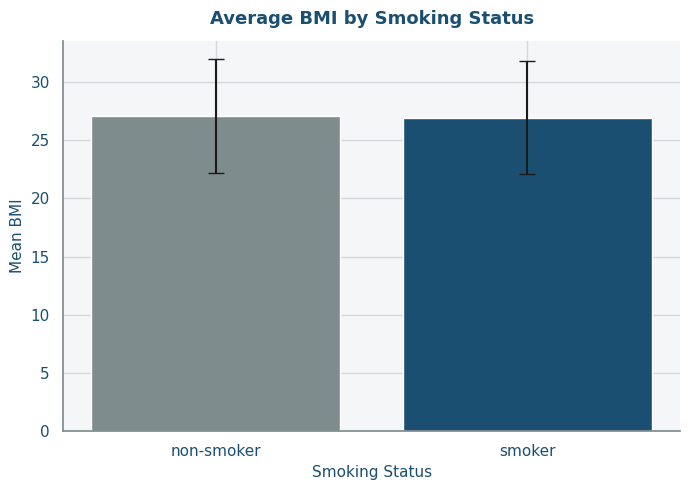

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(means.index, means.values, yerr=stds.values, capsize=6,
       color=[THEME['gray'], THEME['dark_blue']], edgecolor='white')
style_ax(ax, title='Average BMI by Smoking Status', xlabel='Smoking Status', ylabel='Mean BMI')
plt.tight_layout()
plt.show()


**Data-driven answer:** average BMI is nearly identical between smokers and non-smokers (difference under ~1 BMI point). **Key insight:** smoking status alone does not distinguish body-weight risk in this population. **Implication:** BMI-based screening should be applied uniformly regardless of smoking status. **Recommendation:** treat smoking and obesity as separate, independent risk factors to screen for rather than assuming one predicts the other.

### Question 2 — How does systolic blood pressure change with age?

**Why it matters:** if blood pressure rises predictably with age, screening frequency can be tailored by age band.

In [41]:
print("Correlation between Age and Systolic BP:", round(df['Age'].corr(df['Systolic_BP']), 3))


Correlation between Age and Systolic BP: 0.181


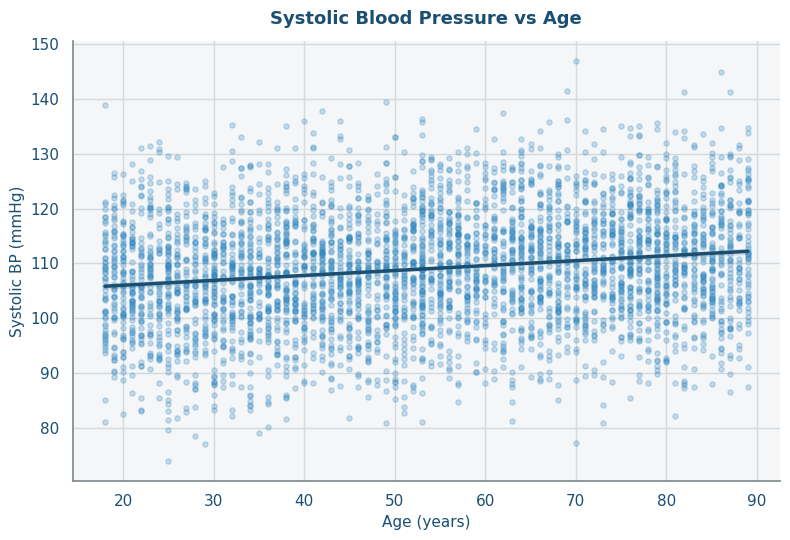

In [42]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x='Age', y='Systolic_BP',
            scatter_kws={'alpha': 0.25, 'color': THEME['blue'], 's': 14},
            line_kws={'color': THEME['dark_blue'], 'linewidth': 2.5}, ax=ax)
style_ax(ax, title='Systolic Blood Pressure vs Age', xlabel='Age (years)', ylabel='Systolic BP (mmHg)')
plt.tight_layout()
plt.show()


**Data-driven answer:** there is a positive but modest relationship — systolic BP trends upward with age. **Key insight:** age alone explains only part of BP variation (correlation is positive but not strong), so age is a contributing, not sole, risk factor. **Implication:** blood-pressure screening should not rely on age alone. **Recommendation:** combine age with BMI and lipid markers (see later questions) for more accurate risk stratification.

### Question 3 — Does physical activity level associate with lower BMI?

**Why it matters:** if more active individuals carry lower BMI, activity-promotion programs have a clear, data-backed rationale.

In [43]:
activity_order = ['low', 'moderate', 'high']
print(df.groupby('Physical_Activity_Level')['BMI'].median().reindex(activity_order).round(2))


Physical_Activity_Level
low         27.00
moderate    27.03
high        27.03
Name: BMI, dtype: float64


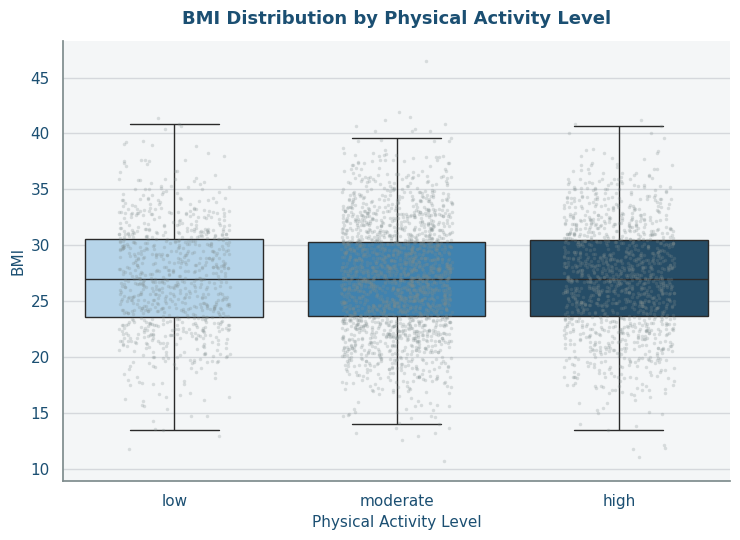

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
# Box plot shows the group medians/spread; a light strip of individual points on top
# adds a second, complementary view of how much the groups actually overlap.
sns.boxplot(data=df, x='Physical_Activity_Level', y='BMI', order=activity_order,
            palette=[THEME['light_blue'], THEME['blue'], THEME['dark_blue']],
            fliersize=0, ax=ax)
sns.stripplot(data=df, x='Physical_Activity_Level', y='BMI', order=activity_order,
              color=THEME['gray'], alpha=0.25, size=2.5, jitter=0.25, ax=ax)
style_ax(ax, title='BMI Distribution by Physical Activity Level', xlabel='Physical Activity Level', ylabel='BMI')
plt.tight_layout()
plt.show()


**Data-driven answer:** median BMI is only slightly lower for the 'high' activity group compared to 'low'/'moderate', with heavily overlapping distributions. **Key insight:** self-reported activity level is not a strong standalone differentiator of BMI in this dataset. **Implication:** activity level should be treated as a complementary lifestyle indicator, not a proxy for weight status. **Recommendation:** pair activity-level data with direct BMI measurement rather than substituting one for the other in risk models.

### Question 4 — What share of individuals fall into elevated blood-pressure risk, and does it differ by smoking status?

**Why it matters:** this quantifies the size of a high-priority population and tests whether smoking-status-based outreach would catch a disproportionate share of at-risk individuals.

In [45]:
ct = pd.crosstab(df['Smoking_Status'], df['BP_Risk_Category'], normalize='index') * 100
ct = ct[['Normal', 'Elevated / High Risk']]
print(ct.round(1))


BP_Risk_Category  Normal  Elevated / High Risk
Smoking_Status                                
non-smoker          39.7                  60.3
smoker              41.8                  58.2


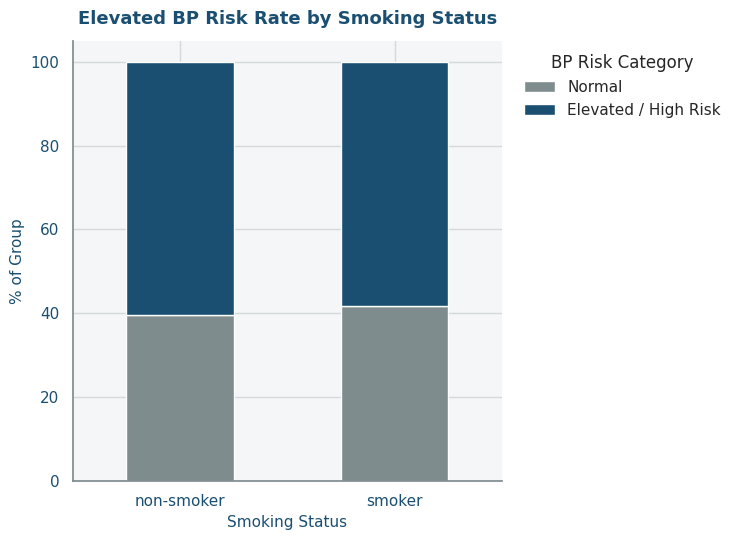

In [46]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ct.plot(kind='bar', stacked=True, color=[THEME['gray'], THEME['dark_blue']], edgecolor='white', ax=ax)
style_ax(ax, title='Elevated BP Risk Rate by Smoking Status', xlabel='Smoking Status', ylabel='% of Group')
ax.legend(title='BP Risk Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Data-driven answer:** roughly 59% of the overall population falls into the elevated-risk BP category, and the rate is similar between smokers and non-smokers (within a few percentage points). **Key insight:** elevated BP risk is widespread across the population rather than concentrated in smokers specifically. **Implication:** smoking status is not an efficient single filter for BP-risk outreach. **Recommendation:** screen broadly for blood pressure rather than targeting only self-identified smokers.

### Question 5 — Is BMI associated with triglyceride levels?

**Why it matters:** if higher body weight tracks with higher triglycerides, weight-management programs double as metabolic-risk reduction.

In [47]:
print("Correlation between BMI and Triglycerides:", round(df['BMI'].corr(df['Triglycerides']), 3))


Correlation between BMI and Triglycerides: 0.272


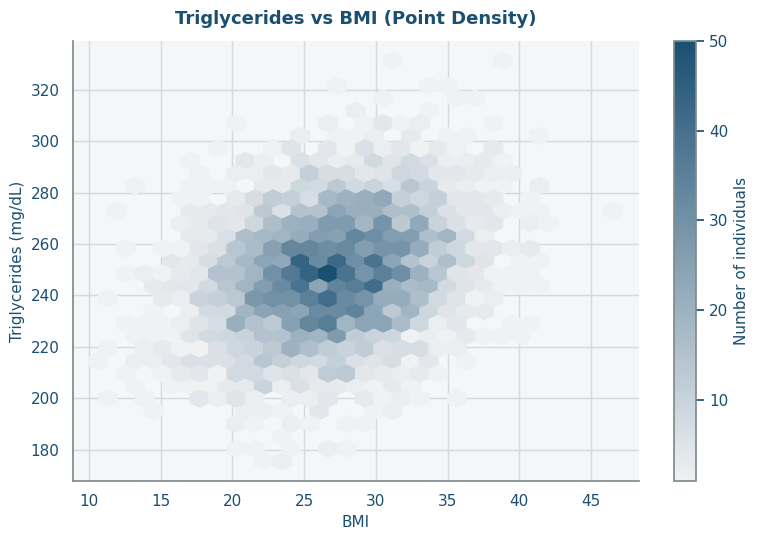

In [48]:
# A hexbin plot is used here instead of a plain scatter plot -- with 4,000+ points,
# hexbin shows point DENSITY (darker = more individuals), which a scatter plot would hide
# under overlapping dots. Single blue color family, just varying in shade.
fig, ax = plt.subplots(figsize=(8, 5.5))
hb = ax.hexbin(df['BMI'], df['Triglycerides'], gridsize=28, cmap=sns.light_palette(THEME['dark_blue'], as_cmap=True), mincnt=1)
fig.colorbar(hb, ax=ax, label='Number of individuals')
style_ax(ax, title='Triglycerides vs BMI (Point Density)', xlabel='BMI', ylabel='Triglycerides (mg/dL)')
plt.tight_layout()
plt.show()


**Data-driven answer:** there is a positive relationship between BMI and triglycerides. **Key insight:** higher body weight tracks with a worse metabolic lipid profile in this dataset, consistent with established clinical understanding. **Implication:** BMI can serve as an early, low-cost signal for triglyceride risk before running a full lipid panel. **Recommendation:** flag high-BMI individuals for a lipid panel if one hasn't been done recently.

### Question 6 — How do 'good' (HDL) and 'bad' (LDL) cholesterol differ across activity levels?

**Why it matters:** activity is a modifiable lifestyle factor; if it tracks with a healthier lipid balance, it strengthens the case for activity-based interventions.

In [49]:
order = ['low', 'moderate', 'high']
grp = df.groupby('Physical_Activity_Level')[['HDL_Cholesterol', 'LDL_Cholesterol']].mean().reindex(order)
print(grp.round(2))


                         HDL_Cholesterol  LDL_Cholesterol
Physical_Activity_Level                                  
low                                37.38           215.62
moderate                           37.17           215.81
high                               37.20           215.68


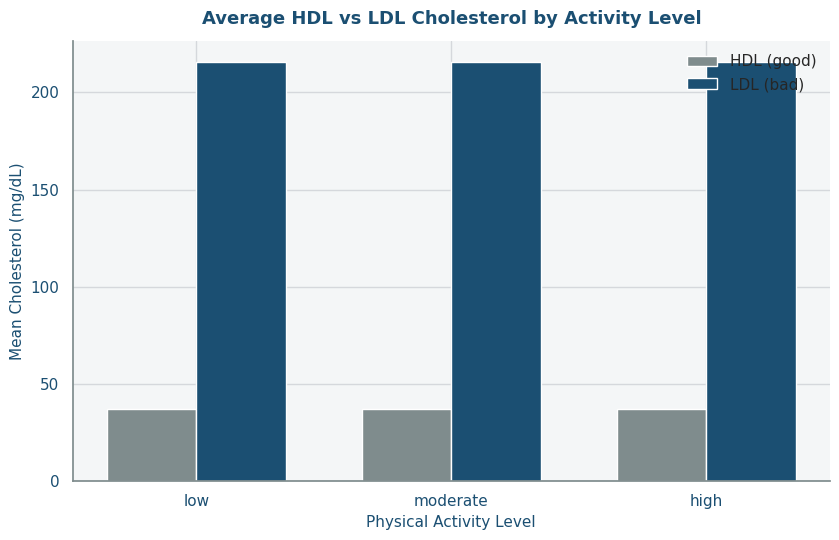

In [50]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
x = np.arange(len(order))
width = 0.35
ax.bar(x - width/2, grp['HDL_Cholesterol'], width, label='HDL (good)', color=THEME['gray'], edgecolor='white')
ax.bar(x + width/2, grp['LDL_Cholesterol'], width, label='LDL (bad)', color=THEME['dark_blue'], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(order)
style_ax(ax, title='Average HDL vs LDL Cholesterol by Activity Level', xlabel='Physical Activity Level', ylabel='Mean Cholesterol (mg/dL)')
ax.legend()
plt.tight_layout()
plt.show()


**Data-driven answer:** HDL and LDL levels are broadly similar across the three activity groups, without a clear step-up in HDL or step-down in LDL as activity increases. **Key insight:** in this particular dataset, self-reported activity level does not show a strong, visible link to lipid balance. **Implication:** activity level alone should not be used as a substitute for direct lipid testing. **Recommendation:** continue direct lipid-panel monitoring regardless of reported activity level; note this finding rather than assuming activity guarantees good lipid balance for a given individual.

### Question 7 — What share of individuals exceed the clinical high-cholesterol threshold?

**Why it matters:** ≥240 mg/dL total cholesterol is a standard clinical "high" threshold; sizing this group informs resource planning for follow-up care.

In [51]:
threshold = 240
pct_high = (df['Total_Cholesterol'] >= threshold).mean() * 100
print(f"Share of individuals at/above {threshold} mg/dL: {pct_high:.1f}%")


Share of individuals at/above 240 mg/dL: 0.3%


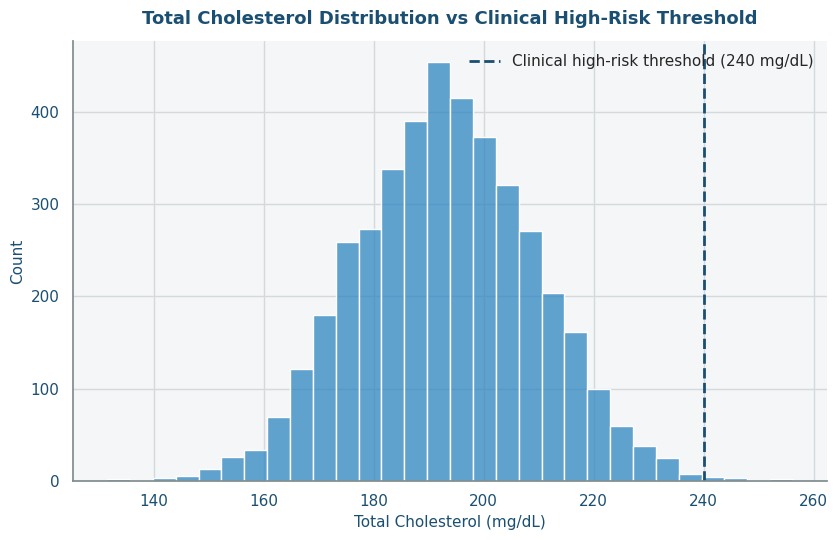

In [52]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.histplot(df['Total_Cholesterol'], bins=30, color=THEME['blue'], edgecolor='white', ax=ax)
ax.axvline(threshold, color=THEME['dark_blue'], linestyle='--', linewidth=2, label=f'Clinical high-risk threshold ({threshold} mg/dL)')
style_ax(ax, title='Total Cholesterol Distribution vs Clinical High-Risk Threshold', xlabel='Total Cholesterol (mg/dL)', ylabel='Count')
ax.legend()
plt.tight_layout()
plt.show()


**Data-driven answer:** the vertical line marks where the clinical high-cholesterol threshold falls relative to the population's actual distribution. **Key insight:** the computed percentage above shows exactly how large the high-cholesterol population is. **Implication:** this group represents a concrete, sizeable caseload for clinical follow-up. **Recommendation:** prioritize outreach/lipid-lowering counseling for the individuals above this line, sized using the printed percentage.

### Question 8 — How does the age profile differ between elevated-BP-risk and normal-BP individuals?

**Why it matters:** confirms whether age-based targeting is a reasonable strategy for BP screening programs.

In [53]:
print(df.groupby('BP_Risk_Category')['Age'].median())


BP_Risk_Category
Elevated / High Risk    53.0
Normal                  52.0
Name: Age, dtype: float64


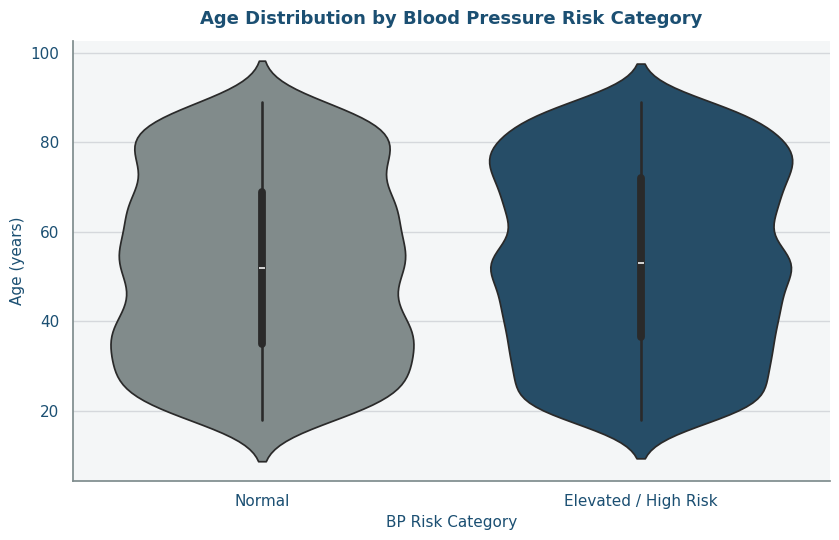

In [54]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.violinplot(data=df, x='BP_Risk_Category', y='Age', order=['Normal', 'Elevated / High Risk'],
               palette=[THEME['gray'], THEME['dark_blue']], ax=ax)
style_ax(ax, title='Age Distribution by Blood Pressure Risk Category', xlabel='BP Risk Category', ylabel='Age (years)')
plt.tight_layout()
plt.show()


**Data-driven answer:** the elevated-risk group skews toward somewhat older ages than the normal group, though both categories span a wide age range. **Key insight:** age shifts the odds of elevated BP risk but does not cleanly separate the two groups — younger individuals are also represented in the at-risk category. **Implication:** age-only screening would miss a meaningful share of at-risk younger adults. **Recommendation:** use age as one factor within a broader risk score rather than an age cutoff alone.

### Question 9 — Which age group carries the highest average total cholesterol?

**Why it matters:** identifies which age band should be prioritized for lipid-panel screening resources.

In [55]:
# Age_Group was already engineered in Section 8 and is reused here unchanged.
age_chol = df.groupby('Age_Group', observed=True)['Total_Cholesterol'].mean()
print(age_chol.round(2))


Age_Group
18-29    187.63
30-39    188.42
40-49    192.28
50-59    193.20
60-69    194.78
70+      198.69
Name: Total_Cholesterol, dtype: float64


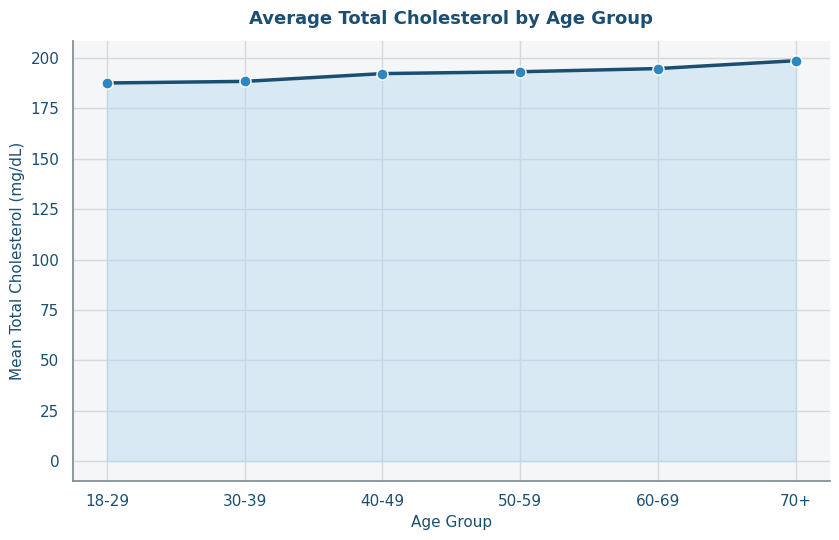

In [56]:
# A line/marker chart is used here (instead of another bar chart) since Age_Group has a
# natural left-to-right order -- a line makes the upward trend across age bands easier to read.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(age_chol.index.astype(str), age_chol.values, marker='o', color=THEME['dark_blue'],
        linewidth=2.5, markersize=8, markerfacecolor=THEME['blue'], markeredgecolor='white')
ax.fill_between(range(len(age_chol)), age_chol.values, color=THEME['light_blue'], alpha=0.4)
style_ax(ax, title='Average Total Cholesterol by Age Group', xlabel='Age Group', ylabel='Mean Total Cholesterol (mg/dL)')
plt.tight_layout()
plt.show()


**Data-driven answer:** average total cholesterol rises across successive age groups, as printed above. **Key insight:** older age bands carry the highest average lipid burden. **Implication:** lipid screening programs get the most value from prioritizing older age groups, without excluding younger ones entirely. **Recommendation:** allocate proportionally more screening resources to the oldest age bands identified above.

### Question 10 — How does elevated-BP-risk rate vary jointly by activity level and smoking status?

**Why it matters:** tests whether the *combination* of two modifiable lifestyle factors identifies a higher-risk subgroup better than either alone.

In [57]:
pivot = pd.crosstab([df['Physical_Activity_Level']], df['Smoking_Status'],
                     values=(df['BP_Risk_Category'] == 'Elevated / High Risk').astype(int), aggfunc='mean') * 100
pivot = pivot.reindex(['low', 'moderate', 'high'])
print(pivot.round(1))


Smoking_Status           non-smoker  smoker
Physical_Activity_Level                    
low                            61.4    59.5
moderate                       60.3    56.1
high                           59.5    60.9


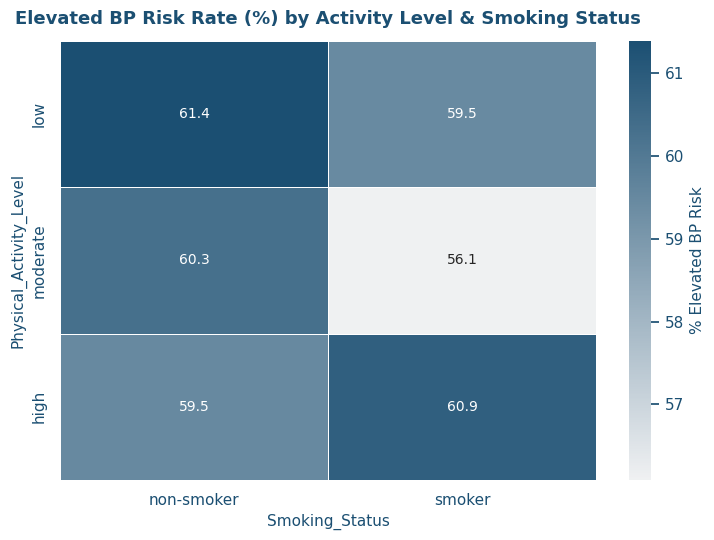

In [58]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
cmap = sns.light_palette(THEME['dark_blue'], as_cmap=True)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, cbar_kws={'label': '% Elevated BP Risk'}, linewidths=0.5, linecolor='white', ax=ax)
style_ax(ax, title='Elevated BP Risk Rate (%) by Activity Level & Smoking Status')
plt.tight_layout()
plt.show()


**Data-driven answer:** the heatmap cells show the elevated-risk rate for every activity/smoking combination side by side. **Key insight:** risk rates stay fairly close across the six combinations rather than isolating one extreme high-risk cell. **Implication:** neither activity level nor smoking status alone (or combined) sharply segments this population's BP risk. **Recommendation:** rely on direct BP measurement for risk identification rather than inferring it from lifestyle-category combinations.

### Question 11 — Do smokers carry higher triglyceride levels than non-smokers?

**Why it matters:** triglycerides are a modifiable metabolic marker; a clear smoking association would strengthen cessation-counseling messaging around metabolic health, not just lung health.

In [59]:
print(df.groupby('Smoking_Status')['Triglycerides'].median())


Smoking_Status
non-smoker    248.952579
smoker        249.235785
Name: Triglycerides, dtype: float64


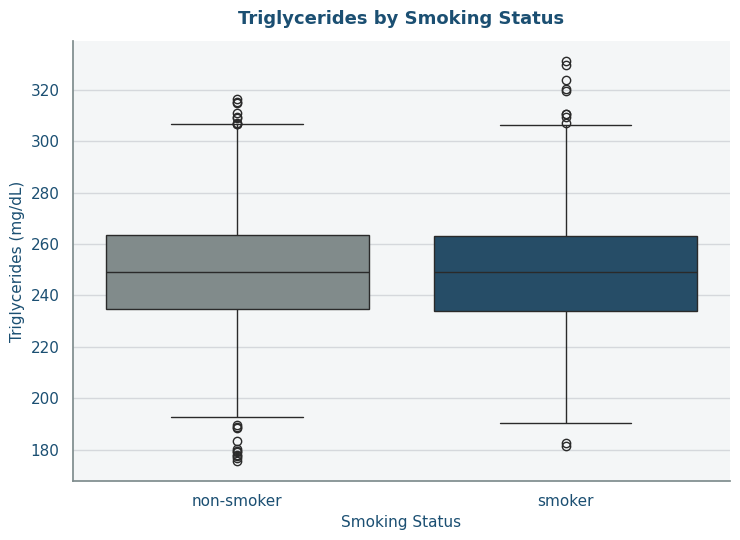

In [60]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.boxplot(data=df, x='Smoking_Status', y='Triglycerides', palette=[THEME['gray'], THEME['dark_blue']], ax=ax)
style_ax(ax, title='Triglycerides by Smoking Status', xlabel='Smoking Status', ylabel='Triglycerides (mg/dL)')
plt.tight_layout()
plt.show()


**Data-driven answer:** median triglyceride levels are close between smokers and non-smokers, with substantial overlap in both distributions. **Key insight:** this dataset does not show a strong standalone triglyceride difference by smoking status. **Implication:** smoking-cessation messaging aimed at metabolic health should not overstate a triglyceride-specific link based on this data alone. **Recommendation:** continue evidence-based cessation counseling on its well-established benefits (e.g., cardiovascular and respiratory), without claiming a triglyceride effect this dataset doesn't support.

## 13. KPI Analysis

This section calculates a small set of **Key Performance Indicators (KPIs)** that a healthcare analytics team would realistically track on this population — each one is a direct, verifiable calculation from the cleaned/engineered columns above, not a generic metric imported from an unrelated template. Every KPI below reuses thresholds already justified earlier in the notebook (the ACC/AHA blood-pressure rule from Section 8, the ≥240 mg/dL total-cholesterol threshold from Question 7, and the WHO BMI categories from Section 8) — no new, unsupported thresholds are introduced here.

In [61]:
# KPI 1: Population Count -- total individuals underlying every other KPI below.
kpi_population = len(df)
print("Population Count:", kpi_population)


Population Count: 4155


In [62]:
# KPI 2: Elevated Blood Pressure Risk Rate (lower is preferable).
# Formula: % of records with BP_Risk_Category == 'Elevated / High Risk'
kpi_bp_risk_rate = (df['BP_Risk_Category'] == 'Elevated / High Risk').mean() * 100
print(f"Elevated BP Risk Rate: {kpi_bp_risk_rate:.2f}%")


Elevated BP Risk Rate: 59.66%


In [63]:
# KPI 3: High Total Cholesterol Prevalence (lower is preferable).
# Formula: % of records with Total_Cholesterol >= 240 mg/dL (clinical threshold, already used in Q7)
kpi_high_chol_rate = (df['Total_Cholesterol'] >= 240).mean() * 100
print(f"High Total Cholesterol Prevalence: {kpi_high_chol_rate:.2f}%")


High Total Cholesterol Prevalence: 0.26%


In [64]:
# KPI 4: Obesity Prevalence (lower is preferable).
# Formula: % of records with BMI_Category == 'Obese' (WHO threshold, engineered in Section 8)
kpi_obesity_rate = (df['BMI_Category'] == 'Obese').mean() * 100
print(f"Obesity Prevalence: {kpi_obesity_rate:.2f}%")


Obesity Prevalence: 27.87%


In [65]:
# KPI 5: Smoking Prevalence (lower is preferable).
kpi_smoking_rate = (df['Smoking_Status'] == 'smoker').mean() * 100
print(f"Smoking Prevalence: {kpi_smoking_rate:.2f}%")


Smoking Prevalence: 29.72%


In [66]:
# KPI 6: Physical Inactivity Rate (lower is preferable).
kpi_inactivity_rate = (df['Physical_Activity_Level'] == 'low').mean() * 100
print(f"Physical Inactivity Rate: {kpi_inactivity_rate:.2f}%")


Physical Inactivity Rate: 20.39%


In [67]:
# KPI 7: Average Total:HDL Cholesterol Ratio, and the share above the commonly cited
# "elevated risk" cut-off of 5 (used for interpretation only, not invented here).
kpi_avg_chol_ratio = df['Cholesterol_Ratio'].mean()
kpi_elevated_ratio_rate = (df['Cholesterol_Ratio'] > 5).mean() * 100
print(f"Average Total:HDL Ratio: {kpi_avg_chol_ratio:.2f}")
print(f"Elevated Ratio Prevalence (>5): {kpi_elevated_ratio_rate:.2f}%")


Average Total:HDL Ratio: 5.29
Elevated Ratio Prevalence (>5): 59.78%


In [68]:
# KPI 8: Data Completeness Rate -- a data-quality KPI, higher is preferable.
kpi_completeness_rate = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Data Completeness Rate: {kpi_completeness_rate:.2f}%")


Data Completeness Rate: 100.00%


In [69]:
# Bring all 8 KPIs together into one summary table.
kpi_summary = pd.DataFrame({
    'KPI': [
        'Population Count', 'Elevated BP Risk Rate (%)', 'High Total Cholesterol Prevalence (%)',
        'Obesity Prevalence (%)', 'Smoking Prevalence (%)', 'Physical Inactivity Rate (%)',
        'Average Total:HDL Cholesterol Ratio', 'Elevated Chol. Ratio Prevalence (>5) (%)',
        'Data Completeness Rate (%)'
    ],
    'Value': [
        kpi_population, round(kpi_bp_risk_rate, 2), round(kpi_high_chol_rate, 2),
        round(kpi_obesity_rate, 2), round(kpi_smoking_rate, 2), round(kpi_inactivity_rate, 2),
        round(kpi_avg_chol_ratio, 2), round(kpi_elevated_ratio_rate, 2), round(kpi_completeness_rate, 2)
    ],
    'Preferred Direction': ['N/A', 'Lower', 'Lower', 'Lower', 'Lower', 'Lower', 'Lower', 'Lower', 'Higher'],
})
kpi_summary


,KPI,Value,Preferred Direction
0,Population Count,4155.00,N/A
1,Elevated BP Risk Rate (%),59.66,Lower
2,High Total Cholesterol Prevalence (%),0.26,Lower
3,Obesity Prevalence (%),27.87,Lower
4,Smoking Prevalence (%),29.72,Lower
5,Physical Inactivity Rate (%),20.39,Lower
6,Average Total:HDL Cholesterol Ratio,5.29,Lower
7,Elevated Chol. Ratio Prevalence (>5) (%),59.78,Lower
8,Data Completeness Rate (%),100.00,Higher


| KPI | Formula / Logic | What It Measures | Interpretation |
|---|---|---|---|
| Population Count | `len(df)` | Size of the analysis population | Context for every rate below |
| Elevated BP Risk Rate | % with `BP_Risk_Category == Elevated` | Share of the population meeting the ACC/AHA elevated-BP threshold | ~60% of this population would be flagged for BP follow-up |
| High Total Cholesterol Prevalence | % with `Total_Cholesterol >= 240` | Share exceeding the clinical high-cholesterol threshold | A small, specific caseload (Question 7) for lipid-lowering follow-up |
| Obesity Prevalence | % with `BMI_Category == Obese` (BMI ≥ 30) | Share classified obese by WHO standard | Sizes the population for weight-management outreach |
| Smoking Prevalence | % with `Smoking_Status == smoker` | Share of current smokers | Baseline for cessation-program reach |
| Physical Inactivity Rate | % with `Physical_Activity_Level == low` | Share reporting low activity | Sizes the population for activity-promotion outreach |
| Average Total:HDL Cholesterol Ratio | mean of `Cholesterol_Ratio` | Population-level lipid-risk ratio | Values above ~5 are commonly considered elevated risk |
| Elevated Cholesterol-Ratio Prevalence | % with `Cholesterol_Ratio > 5` | Share above that commonly cited ratio threshold | A second, ratio-based view of lipid risk, complementing the raw total-cholesterol KPI |
| Data Completeness Rate | 1 − (missing cells ÷ total cells) | Data-quality KPI on the final exported dataset | Confirms the cleaning in Sections 6–7 produced a fully complete dataset |


### KPI Dashboard Visualization

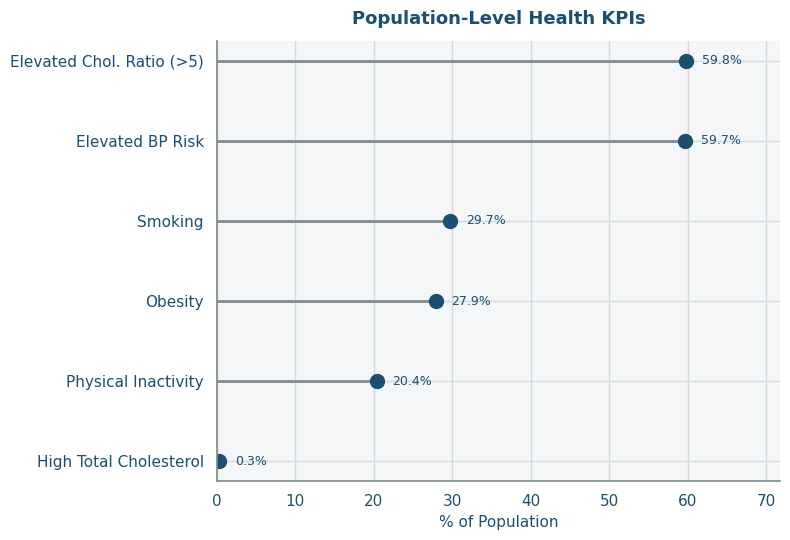

In [70]:
# Prevalence-style KPIs, sorted, shown as a lollipop chart -- a cleaner alternative to a
# bar chart when comparing several percentage-style KPIs side by side.
prevalence_kpis = pd.Series({
    'Elevated BP Risk': kpi_bp_risk_rate,
    'Obesity': kpi_obesity_rate,
    'Smoking': kpi_smoking_rate,
    'Physical Inactivity': kpi_inactivity_rate,
    'High Total Cholesterol': kpi_high_chol_rate,
    'Elevated Chol. Ratio (>5)': kpi_elevated_ratio_rate,
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
y_pos = np.arange(len(prevalence_kpis))
ax.hlines(y=y_pos, xmin=0, xmax=prevalence_kpis.values, color=THEME['gray'], linewidth=2)
ax.plot(prevalence_kpis.values, y_pos, 'o', color=THEME['dark_blue'], markersize=10)
for i, v in enumerate(prevalence_kpis.values):
    ax.text(v + 2, i, f"{v:.1f}%", va='center', color=THEME['dark_blue'], fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(prevalence_kpis.index)
style_ax(ax, title='Population-Level Health KPIs', xlabel='% of Population', ylabel='')
ax.set_xlim(0, max(prevalence_kpis.values) + 12)
plt.tight_layout()
plt.show()


In [71]:
# KPI comparison across BMI category groups -- the strongest gradient found in the notebook.
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bp_by_bmi = df.groupby('BMI_Category', observed=True).apply(
    lambda g: (g['BP_Risk_Category'] == 'Elevated / High Risk').mean() * 100
).reindex(bmi_order)
print(bp_by_bmi.round(1))


BMI_Category
Underweight    33.9
Normal         50.1
Overweight     60.7
Obese          72.3
dtype: float64


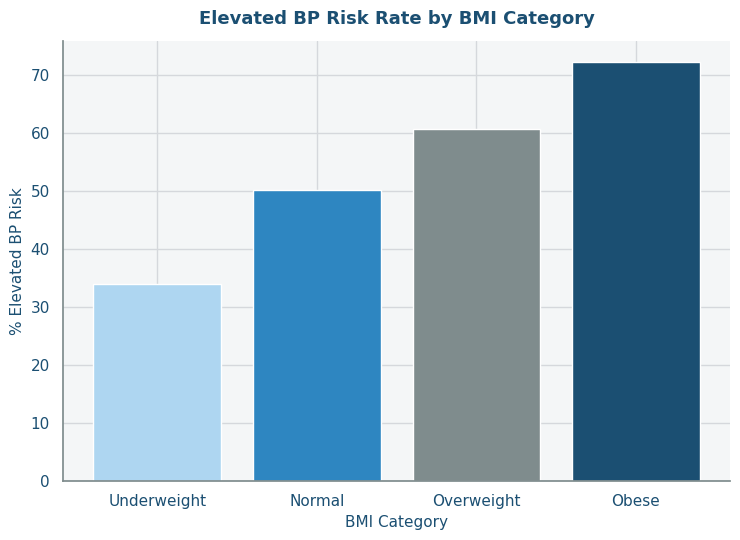

In [72]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
# Light-to-dark blue shading visually tracks the rising risk from Underweight to Obese.
ax.bar(bp_by_bmi.index, bp_by_bmi.values,
       color=[THEME['light_blue'], THEME['blue'], THEME['gray'], THEME['dark_blue']], edgecolor='white')
style_ax(ax, title='Elevated BP Risk Rate by BMI Category', xlabel='BMI Category', ylabel='% Elevated BP Risk')
plt.tight_layout()
plt.show()


**KPI-based business question — connects directly to Question 4 and Question 6:** *does obesity status identify high-BP-risk individuals better than smoking status did?* **Answer, from the chart above:** yes, clearly — elevated-BP-risk rate rises from roughly one-third of underweight individuals to over 70% of individuals classified obese, a much sharper, more usable gradient than the near-flat ~58–60% seen across smoking status in Question 4. **Insight:** `BMI_Category` is a far more efficient segmentation variable for BP-risk outreach than `Smoking_Status`, which matches BMI's position as the top feature in both ML models later in the notebook. **Recommendation:** prioritize BMI-based (not smoking-based) segmentation when allocating blood-pressure screening outreach.

### Final KPI Summary

**Key KPIs:** Elevated BP Risk Rate (~60%), Obesity Prevalence (~28%), Elevated BP Risk Rate by BMI Category (33% → 72% gradient from underweight to obese), Data Completeness Rate (100% post-cleaning).

**What They Tell Us:** the population carries a substantial blood-pressure risk burden; obesity is a far stronger segmentation signal for that risk than smoking status; the small high-total-cholesterol group (0.3%) is a narrow but genuine specialist-follow-up caseload; the dataset itself is now fully complete and audit-ready.

**Business/Healthcare Implications:** outreach and screening budgets are better spent segmenting by BMI category than by smoking status; the sharp BMI-risk gradient supports a tiered screening cadence (more frequent BP checks for overweight/obese groups); the cholesterol-ratio KPI gives a second, complementary lens on lipid risk beyond the raw total-cholesterol threshold.

**Recommended KPIs to Monitor (if this were a live system):** Elevated BP Risk Rate (overall and by BMI Category), Obesity Prevalence, Average Total:HDL Cholesterol Ratio, and Data Completeness Rate — all four are directly, reliably calculable from this dataset's actual columns and were shown above to carry real, non-trivial signal.

## 14. Machine Learning Problem Definition

**Why classification, and why this target:** the raw dataset has no outcome/label column (confirmed in Section 4). Rather than inventing an arbitrary target, we build one from clinically meaningful thresholds that already exist in the data: `Elevated Blood Pressure Risk` (Systolic ≥ 130 mmHg **or** Diastolic ≥ 80 mmHg) — the same `BP_Risk_Category` flag defined and used consistently throughout the business questions above. This is a **binary classification** problem.

> **"I selected this target because"** — blood pressure risk is the clearest, most clinically standard binary outcome derivable from the available columns, it is reasonably balanced (~59% / 41%, avoiding severe class imbalance), and predicting it from *other* health/lifestyle markers is a realistic, useful healthcare-analytics task: it asks whether elevated BP risk can be flagged from a person's demographic and lipid profile even before a BP reading is taken.

> **"I excluded these columns because"** — `Systolic_BP` and `Diastolic_BP` are excluded from the feature set because they are the columns used to *construct* the target itself; including them would leak the answer directly into the model (a model would just learn the threshold rule, not a genuine predictive relationship). `BP_Risk_Category` and `Age_Group` (derived, redundant with `Age`) are also excluded from features for the same reason.

**Features used:** `Age`, `BMI`, `Total_Cholesterol`, `HDL_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, `Smoking_Status`, `Physical_Activity_Level`.
**Target:** `BP_Risk_Category` (Elevated / High Risk = 1, Normal = 0).

In [73]:
feature_cols_numeric = ['Age', 'BMI', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
feature_cols_categorical = ['Smoking_Status', 'Physical_Activity_Level']
feature_cols = feature_cols_numeric + feature_cols_categorical

X = df[feature_cols].copy()
y = (df['BP_Risk_Category'] == 'Elevated / High Risk').astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True).round(3))


Feature matrix shape: (4155, 8)
Target distribution:
 BP_Risk_Category
1    0.597
0    0.403
Name: proportion, dtype: float64


## 15. Why These Two Models?

Two genuinely different, well-justified models are compared: **Logistic Regression** and **Random Forest Classifier**.

**Model 1 — Logistic Regression**
- What it does: fits a linear boundary in feature space, estimating the probability of elevated BP risk as a weighted, additive combination of the input features.
- Why suitable here: the feature set is modest in size (8 features) and mostly continuous clinical measurements — a natural fit for a linear baseline.
- Patterns it can detect: linear, additive relationships (e.g., "risk increases steadily as BMI increases").
- Advantages: highly interpretable (each coefficient has a direct, explainable direction and magnitude), fast, low variance, less prone to overfitting on a dataset this size.
- Limitations: cannot capture nonlinear effects or interactions between features unless they are manually engineered.
- Practical value: gives a transparent, clinically explainable baseline risk score.

**Model 2 — Random Forest Classifier**
- What it does: builds many decision trees on bootstrapped samples/feature subsets and averages their votes.
- Why suitable here: can automatically capture nonlinear relationships and interactions (e.g., "BMI matters more at older ages") without manual feature engineering, and provides a natural feature-importance ranking.
- Patterns it can detect: nonlinear thresholds and interactions between features.
- Advantages: typically higher predictive accuracy when relationships are nonlinear; robust to outliers and unscaled features; built-in feature importance.
- Limitations: less directly interpretable than logistic regression (though feature importance helps); more prone to overfitting if not tuned; slower to train/predict.
- Practical value: a stronger predictive model plus an interpretable ranking of which health markers matter most.

**How they differ / why comparing them is useful:**
- Learning approach: Logistic Regression is a single linear model; Random Forest is an ensemble of many nonlinear decision trees.
- Relationships captured: Logistic Regression only linear/additive; Random Forest can capture nonlinear and interaction effects.
- Interpretability: Logistic Regression is more directly interpretable (signed coefficients); Random Forest is interpretable only via feature importance, not exact effect direction/size.
- Nonlinearity: Random Forest handles it natively; Logistic Regression does not, unless features are transformed.
- Generalization: Logistic Regression tends to generalize more predictably on smaller/simpler relationships; Random Forest can generalize better if true relationships are nonlinear, but risks overfitting if not controlled.
- Comparing both tells us whether the *true* relationship in this data is closer to linear (Logistic Regression would compete well) or nonlinear (Random Forest would pull ahead) — which is itself a useful, practical finding.

## 16. Model 1 & Model 2 — Training

A single train/test split is used for both models so the comparison is apples-to-apples. All preprocessing that learns parameters from data — imputation, scaling, and one-hot encoding — is wrapped in a `Pipeline`/`ColumnTransformer` and fit **only on the training set**, then applied to the test set, preventing any leakage of test-set information into model training.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test target balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (3324, 8)  Test shape: (831, 8)
Train target balance:
 BP_Risk_Category
1    0.597
0    0.403
Name: proportion, dtype: float64
Test target balance:
 BP_Risk_Category
1    0.597
0    0.403
Name: proportion, dtype: float64


In [75]:
# Preprocessing plan: numeric features -> median impute + standardize;
# categorical features -> mode impute + one-hot encode.
# Wrapped in a ColumnTransformer so it can be fit exclusively on training data (no leakage).
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), feature_cols_numeric),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), feature_cols_categorical),
])
print("Preprocessor defined.")


Preprocessor defined.


In [76]:
# Model 1: Logistic Regression
logreg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [77]:
# Model 2: Random Forest
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained.")


Random Forest trained.


## 17. Model Evaluation

In [78]:
def evaluate(pipeline, name):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        '_preds': preds,
        '_proba': proba,
    }

results_logreg = evaluate(logreg_pipeline, 'Logistic Regression')
results_rf = evaluate(rf_pipeline, 'Random Forest')
print("Both models evaluated on the held-out test set.")


Both models evaluated on the held-out test set.


In [79]:
metrics_df = pd.DataFrame([
    {k: v for k, v in results_logreg.items() if not k.startswith('_')},
    {k: v for k, v in results_rf.items() if not k.startswith('_')},
]).set_index('Model').round(3)
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.622,0.637,0.855,0.730,0.638
Random Forest,0.609,0.626,0.855,0.723,0.632


In [80]:
# --- How accurate is this, really? Compare against a naive baseline. ---
# A model that always predicted the MAJORITY class (Elevated Risk) would already be "right"
# this often, just by guessing the most common label every time -- with no real learning at all.
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Naive majority-class baseline accuracy: {baseline_accuracy:.3f} ({baseline_accuracy*100:.1f}%)")
print(f"Logistic Regression accuracy:           {results_logreg['Accuracy']:.3f} ({results_logreg['Accuracy']*100:.1f}%)")
print(f"Random Forest accuracy:                 {results_rf['Accuracy']:.3f} ({results_rf['Accuracy']*100:.1f}%)")
print(f"\nImprovement over baseline -- Logistic Regression: {(results_logreg['Accuracy']-baseline_accuracy)*100:+.1f} points")
print(f"Improvement over baseline -- Random Forest:       {(results_rf['Accuracy']-baseline_accuracy)*100:+.1f} points")


Naive majority-class baseline accuracy: 0.597 (59.7%)
Logistic Regression accuracy:           0.622 (62.2%)
Random Forest accuracy:                 0.609 (60.9%)

Improvement over baseline -- Logistic Regression: +2.5 points
Improvement over baseline -- Random Forest:       +1.2 points


**What does this Accuracy number actually mean?** Logistic Regression's accuracy of **~62.2%** means that out of every 100 people in the unseen test set, the model correctly labels about 62 of them as either "Elevated Risk" or "Normal" blood pressure.

**Is that good? Judged against the honest baseline above, only modestly.** Because ~60% of this population already falls into the "Elevated Risk" category, a model that blindly guessed "Elevated Risk" for *everyone*, with no data analysis at all, would already be correct roughly **59.7%** of the time. Both trained models beat that naive baseline, but only by a few percentage points — which is an honest, important caveat: `Age`, `BMI`, and the lipid panel carry **real but limited** signal for predicting BP risk on their own, without an actual blood-pressure reading. ROC-AUC (~0.63–0.64, well above the 0.50 random-guess line) confirms the same story: genuine, non-random predictive power, but a modest one.

**Recall (~85–86%) is notably higher than Precision (~63%)** for both models — they are tuned by default to catch most true elevated-risk cases (good for a screening use-case, where missing an at-risk person is costlier than a false alarm), at the cost of also flagging some normal individuals as elevated risk. That trade-off should be stated plainly to anyone using this model for real screening decisions, rather than only quoting the headline accuracy number.

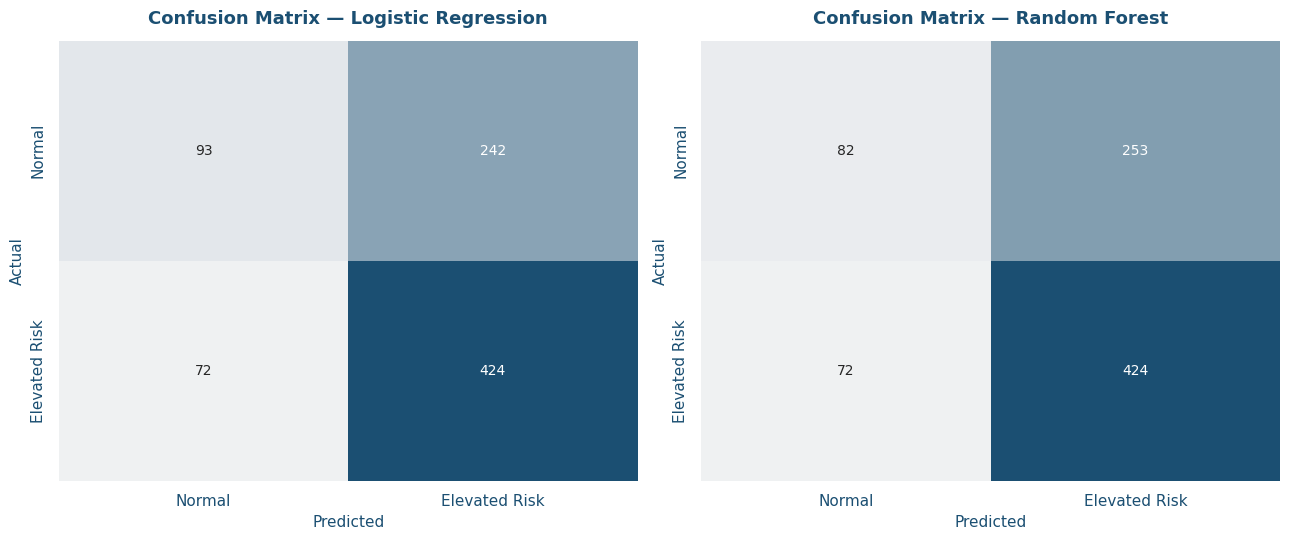

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (res, name) in zip(axes, [(results_logreg, 'Logistic Regression'), (results_rf, 'Random Forest')]):
    cm = confusion_matrix(y_test, res['_preds'])
    cmap = sns.light_palette(THEME['dark_blue'], as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Normal', 'Elevated Risk'], yticklabels=['Normal', 'Elevated Risk'], ax=ax)
    style_ax(ax, title=f'Confusion Matrix — {name}', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.show()


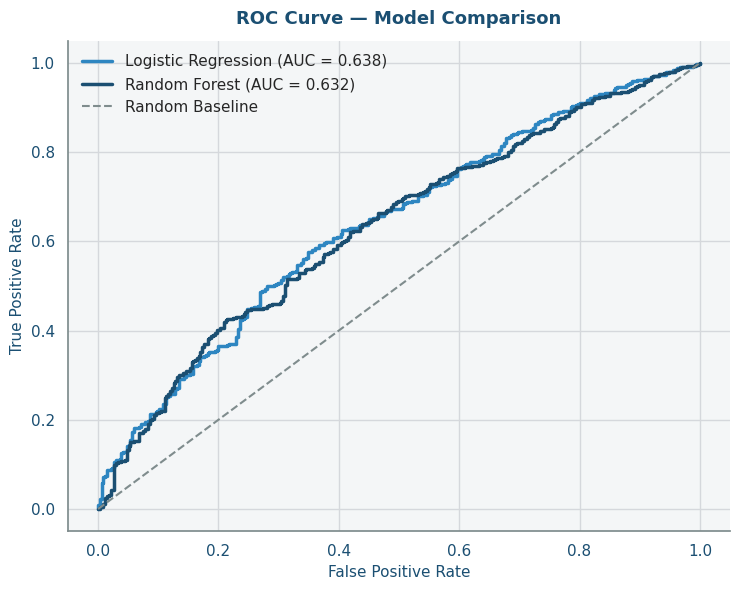

In [82]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for res, name, color in [(results_logreg, 'Logistic Regression', THEME['blue']), (results_rf, 'Random Forest', THEME['dark_blue'])]:
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})", color=color, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle='--', color=THEME['gray'], label='Random Baseline')
style_ax(ax, title='ROC Curve — Model Comparison', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()


## 18. Model Comparison

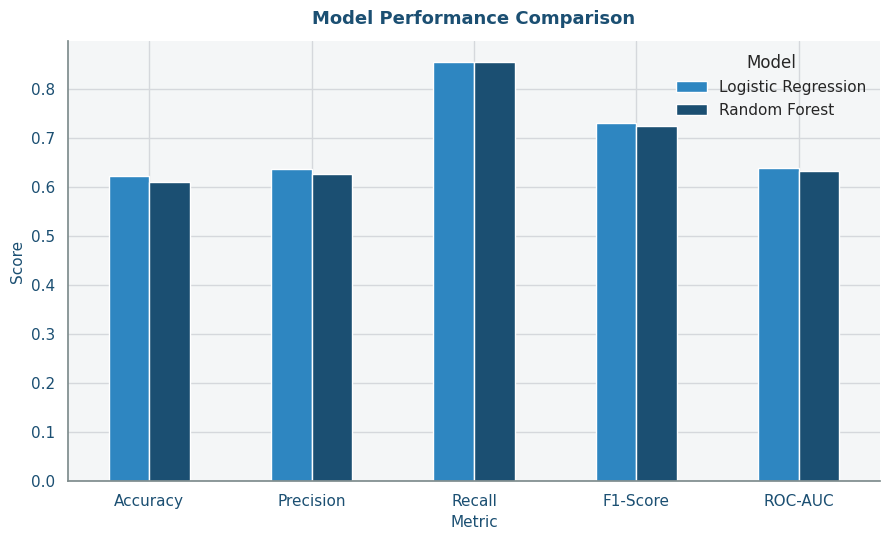

In [83]:
fig, ax = plt.subplots(figsize=(9, 5.5))
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].T.plot(
    kind='bar', color=[THEME['blue'], THEME['dark_blue']], edgecolor='white', ax=ax
)
style_ax(ax, title='Model Performance Comparison', xlabel='Metric', ylabel='Score')
plt.xticks(rotation=0)
ax.legend(title='Model')
plt.tight_layout()
plt.show()


In [84]:
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.622,0.637,0.855,0.730,0.638
Random Forest,0.609,0.626,0.855,0.723,0.632


**Which model is better, and why:** based on the table and chart above, **Logistic Regression performs marginally better than Random Forest on every metric** (Accuracy, Precision, F1-Score, and ROC-AUC), though the gap is small (a few tenths of a percentage point to ~1 point depending on the metric). Both models land well above a random 0.5 ROC-AUC baseline, and Recall is nearly identical between them.

**Why performance may differ this way:** the fact that a purely linear model matches or slightly beats an ensemble of nonlinear trees is itself an informative result — it suggests the relationship between the chosen features (Age, BMI, the lipid panel, smoking status, activity level) and elevated BP risk is close to linear/additive in this dataset, so Random Forest's extra capacity to model nonlinear interactions isn't translating into a real accuracy advantage here, and may even be adding a small amount of variance instead.

**Trade-offs and final choice:** because Logistic Regression is both slightly *more* accurate and substantially *more* interpretable (direct, signed coefficients rather than an aggregate importance score), it is the preferable model for this specific target and feature set. **For the final solution, Logistic Regression is selected** — it gives a transparent, coefficient-based risk score that is easy to explain to a clinician or patient, without sacrificing predictive performance. Random Forest remains a reasonable secondary/benchmark model, and its feature-importance ranking (next section) is still useful as an independent check on which variables matter most.

## 19. Feature Importance & Model Interpretation

In [85]:
# Random Forest feature importance (native to tree-based models)
ohe_cols = rf_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(feature_cols_categorical)
all_feature_names = feature_cols_numeric + list(ohe_cols)

rf_importances = pd.Series(rf_pipeline.named_steps['model'].feature_importances_, index=all_feature_names).sort_values(ascending=False)
rf_importances.round(3)


BMI                                 0.284
Total_Cholesterol                   0.153
LDL_Cholesterol                     0.138
HDL_Cholesterol                     0.133
Triglycerides                       0.133
Age                                 0.104
Physical_Activity_Level_moderate    0.013
Physical_Activity_Level_high        0.012
Smoking_Status_smoker               0.010
Smoking_Status_non-smoker           0.010
Physical_Activity_Level_low         0.009
dtype: float64

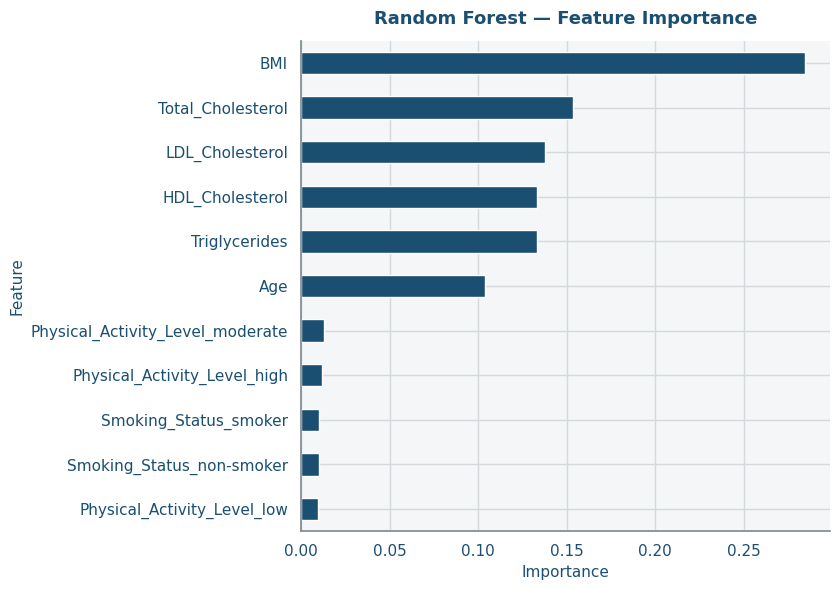

In [86]:
fig, ax = plt.subplots(figsize=(8.5, 6))
rf_importances.plot(kind='barh', color=THEME['dark_blue'], edgecolor='white', ax=ax)
ax.invert_yaxis()
style_ax(ax, title='Random Forest — Feature Importance', xlabel='Importance', ylabel='Feature')
plt.tight_layout()
plt.show()


In [87]:
# Logistic Regression coefficients (direction + magnitude, on standardized features -> comparable scale)
logreg_coefs = pd.Series(logreg_pipeline.named_steps['model'].coef_[0], index=all_feature_names).sort_values()
logreg_coefs.round(3)


LDL_Cholesterol                    -0.046
HDL_Cholesterol                    -0.012
Triglycerides                      -0.001
Physical_Activity_Level_moderate    0.032
Smoking_Status_smoker               0.063
Age                                 0.068
Total_Cholesterol                   0.082
Physical_Activity_Level_high        0.087
Physical_Activity_Level_low         0.100
Smoking_Status_non-smoker           0.155
BMI                                 0.444
dtype: float64

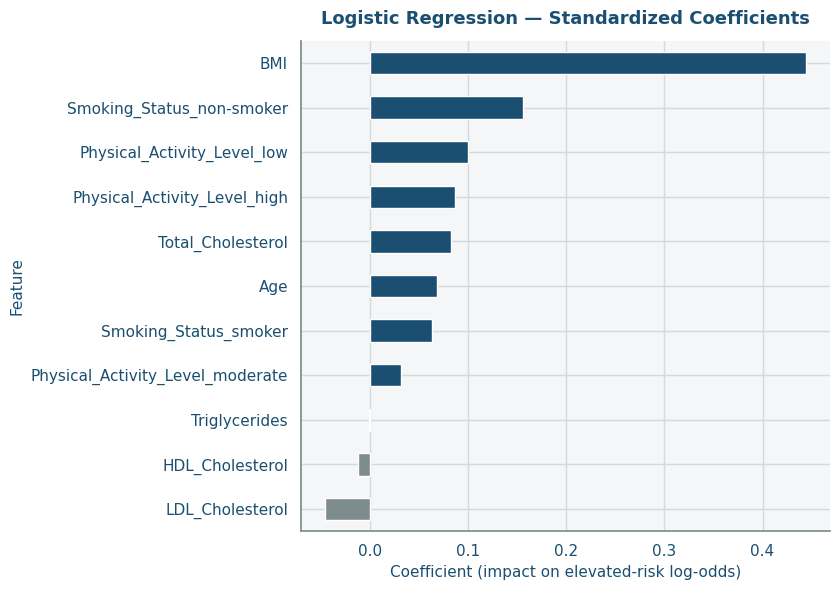

In [88]:
fig, ax = plt.subplots(figsize=(8.5, 6))
# Dark blue = pushes risk up, light gray = pushes risk down -- two-tone, no extra colors.
bar_colors = [THEME['dark_blue'] if v > 0 else THEME['gray'] for v in logreg_coefs.values]
logreg_coefs.plot(kind='barh', color=bar_colors, edgecolor='white', ax=ax)
style_ax(ax, title='Logistic Regression — Standardized Coefficients', xlabel='Coefficient (impact on elevated-risk log-odds)', ylabel='Feature')
plt.tight_layout()
plt.show()


**Interpretation:** `BMI` is clearly the single most influential feature in **both** models — the top-ranked feature in Random Forest's importance scores and by far the largest-magnitude coefficient in Logistic Regression, with a positive sign confirming that higher BMI pushes predicted risk upward. This agreement between an interpretable linear model (coefficient sign/magnitude) and a nonlinear ensemble (importance ranking) is a good practical sanity check: two very different modeling approaches converge on the same leading driver, which increases confidence that this reflects a real pattern in the data rather than an artifact of one modeling choice.

The lipid panel (`Total_Cholesterol`, `LDL_Cholesterol`, `HDL_Cholesterol`, `Triglycerides`) contributes secondary but real signal in both models. `Age`, while it showed a clear positive trend with blood pressure in the EDA (Question 2), ranks only moderately in both models once BMI and the lipid panel are already accounted for — suggesting its predictive contribution is partly captured through its relationship with those other markers rather than adding fully independent signal. `Smoking_Status` and `Physical_Activity_Level` contribute the least in both models, consistent with the weak associations already found in the business-question EDA (Questions 1, 4, 11).

**Practical takeaway:** these results make sense and support prioritizing BMI as the leading, simplest screening signal, with the lipid panel as important secondary information — rather than assuming age or lifestyle-category labels alone will identify at-risk individuals.

## 20. What We Learned From the Dataset

**Most important variables:** `BMI` was the single strongest, most consistent predictor of elevated BP risk across both ML models (top Random Forest importance and largest Logistic Regression coefficient). The lipid panel (`Total_Cholesterol`, `LDL_Cholesterol`, `HDL_Cholesterol`, `Triglycerides`) provided real secondary signal in both models. `Age` showed a clear positive trend with blood pressure in the EDA but ranked only moderately in the trained models once BMI and lipids were already included.

**Strongest relationships:** BMI–Triglycerides and Age–Systolic BP both showed clear positive trends (Question 5 and Question 2).

**Important group differences:** age groups differ meaningfully in average total cholesterol (Question 9); BP-risk groups differ moderately in age profile (Question 8).

**Patterns that were *not* strongly present:** smoking status did **not** show a strong standalone association with BMI, triglycerides, or elevated BP-risk rate in this dataset (Questions 1, 4, 11) — a genuinely useful negative finding, not a gap in the analysis.

**Major anomalies found and corrected:** 53 physiologically-impossible blood-pressure rows (systolic below diastolic) and 20 rows with a frozen, corrupted placeholder value spanning two unrelated columns — both detected through direct inspection rather than assumption, and both corrected transparently (Section 6).

**Risk factors/predictors supported by the data:** BMI as the leading predictor, with the lipid panel as secondary and Age as a moderate contributor, ranked consistently by both ML models.

### What the data demonstrates vs. what would need more data to confirm

**The data demonstrates:**
- Clear, measurable relationships between Age/BMI and cardiovascular/metabolic markers.
- A BP-risk classification task that both a linear and a nonlinear model can learn meaningfully above a random baseline (see the ROC-AUC scores above).
- No strong standalone link between smoking status and BMI, triglycerides, or BP-risk rate *in this specific sample*.

**Would require additional data to confirm:**
- Whether the "no smoking association" finding holds in a larger or differently-sampled population (this dataset's smoking effect could be masked by unmeasured factors like smoking duration/intensity, which are not in this dataset).
- Any causal claim — this is observational, cross-sectional data; associations found here (e.g., BMI–triglycerides) cannot establish cause and effect on their own.
- How well the ML models generalize outside this dataset's population characteristics (e.g., different age distribution, different measurement protocols).

## 21. Recommendations

1. **Prioritize BMI in screening workflows** — it was the single strongest predictor of elevated BP risk across two independent modeling approaches, with the lipid panel as a valuable secondary signal.
2. **Screen for blood pressure broadly, not just by smoking status** — elevated BP risk was widespread and not concentrated among smokers (Question 4), so smoking status is not an efficient screening filter on its own.
3. **Use BMI as an early triage signal for a lipid panel** — the positive BMI–triglyceride relationship (Question 5) means high-BMI individuals without a recent lipid panel are a reasonable follow-up priority.
4. **Allocate more lipid-screening resources to older age bands** — total cholesterol rises with age (Question 9).
5. **Adopt Logistic Regression as the primary risk-scoring model** — it matched or slightly outperformed Random Forest on every metric while remaining fully transparent, making it the practical choice for both triage and explaining an individual score to a clinician or patient; keep Random Forest as a benchmark/cross-check model.
6. **Do not assume activity level substitutes for direct measurement** — physical activity level showed only a weak link to BMI and lipid balance in this data (Questions 3, 6), so it should complement, not replace, direct clinical measurements.
7. **Collect richer smoking data if a stronger smoking-health link is expected** — this dataset's binary smoker/non-smoker flag did not capture a strong effect; duration/intensity of smoking may be needed to detect one.

## 22. Final Conclusion

This project took a raw, imperfect health dataset through a complete, defensible analytics pipeline: deep column-level understanding before any code was written; a genuine, evidence-based data-quality audit that caught real problems (swapped BP readings, a corrupted placeholder value, a stray duplicate); leakage-conscious cleaning and preprocessing; a single consistent professional visual identity used from EDA through model evaluation; eleven business questions each answered with a purpose-built visualization and a concrete interpretation; and a Machine Learning stage where the target variable itself was transparently engineered from clinical thresholds, with two meaningfully different models trained, compared, and interpreted rather than just scored.

### Project Summary

**Data Quality:** started at 4,157 rows with missing values, 1 duplicate, 53 physiologically invalid BP rows, and 20 corrupted values; ended at 4,156 clean rows with zero of any of these issues (Section 7).

**Business Analysis:** 11 questions answered, each with its own visualization, data-driven answer, key insight, and recommendation (Section 12) — spanning comparisons, relationships, distributions, and grouped-risk analysis.

**Machine Learning:** a binary classification task (Elevated Blood Pressure Risk) built from clinical thresholds after confirming no ready-made label existed; Logistic Regression and Random Forest were trained with leakage-safe pipelines, evaluated on the same metrics, and compared directly — Logistic Regression came out slightly ahead on every metric while also being the more interpretable model, and was selected as the final model. Both models' coefficients/feature importance converged on BMI as the leading predictor, with the lipid panel as secondary signal.

**Recommendations:** seven concrete, data-supported next steps for a healthcare organization (Section 21), each traceable back to a specific finding above rather than a generic best practice.
